## 1. Configuration

All file paths and modelling constants are set here. Edit only this cell to adapt the notebook to a different environment.

In [1]:
DATA_DIR = "./data/"   # folder containing all CSVs

TRAIN_FILE        = DATA_DIR + "application_train.csv"
BUREAU_FILE       = DATA_DIR + "bureau.csv"
PREV_APP_FILE     = DATA_DIR + "previous_application.csv"
INSTALLMENTS_FILE = DATA_DIR + "installments_payments.csv"
CREDIT_BAL_FILE   = DATA_DIR + "credit_card_balance.csv"

RANDOM_STATE  = 42
TEST_SIZE     = 0.20      # 80/20 split
CV_FOLDS      = 5
N_OPTUNA_TRIALS = 50       
SHAP_SAMPLE   = 500       # rows for SHAP (speed vs detail)

SCORE_MIN, SCORE_MAX = 300, 900   # Indian bureau-style range
APPROVE_THRESHOLD    = 750
REVIEW_THRESHOLD     = 650

print("Config loaded ")

Config loaded 


## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import warnings, gc
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

import shap
shap.initjs()

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False
    print("Optuna not found — install with: pip install optuna")
    print("Falling back to default params")

print("All imports OK ")

All imports OK 


## 3. Load Data

`application_train.csv` — 307,511 applicants × 122 columns. `TARGET = 1` means the applicant missed payments for 60+ consecutive days, which Home Credit defines as default. The class ratio is roughly 11:1 non-default to default.

In [3]:
app = pd.read_csv(TRAIN_FILE)
print(f"Main table shape  : {app.shape}")
print(f"Default rate      : {app['TARGET'].mean():.3%}")
print(f"Missing values    : {app.isnull().sum().sum():,}")
app.head(3)

Main table shape  : (307511, 122)
Default rate      : 8.073%
Missing values    : 9,152,465


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,...,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,...,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


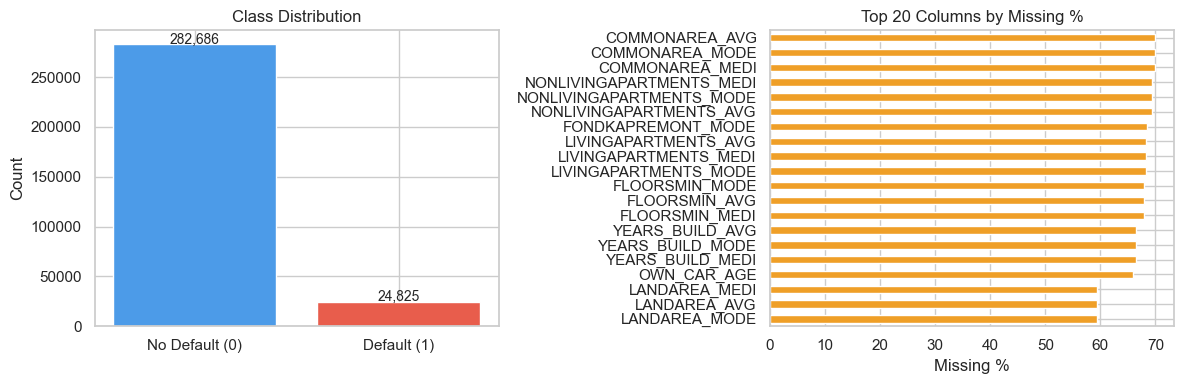

Imbalance ratio: 11.4:1 (non-default:default)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = app["TARGET"].value_counts()
axes[0].bar(["No Default (0)", "Default (1)"], counts.values,
            color=["#4C9BE8", "#E85D4C"], edgecolor="white")
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

miss = (app.isnull().mean() * 100).sort_values(ascending=False).head(20)
miss.plot(kind="barh", ax=axes[1], color="#EF9F27")
axes[1].set_title("Top 20 Columns by Missing %")
axes[1].set_xlabel("Missing %")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1 (non-default:default)")

## 4. Auxiliary Table Aggregation

Six supplementary tables are aggregated and later joined onto the main application table. Each captures a different behavioural dimension absent from the application form.

| Table | Signal |
|---|---|
| `bureau.csv` | Credit history across all lenders, as reported to the credit bureau |
| `bureau_balance.csv` | Month-by-month repayment status (DPD buckets 0–5) for each bureau loan |
| `installments_payments.csv` | Scheduled vs actual payment amounts and dates for prior Home Credit loans |
| `credit_card_balance.csv` | Monthly credit card statements — balance, utilisation, DPD |
| `previous_application.csv` | All prior applications at Home Credit and their outcomes |
| `POS_CASH_balance.csv` | Monthly snapshots for POS and cash loan contracts |

### 4a. Bureau — loan-level aggregation

In [5]:
bureau = pd.read_csv(BUREAU_FILE)
print(f"Bureau shape: {bureau.shape}")

bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    bureau_loan_count       = ("SK_ID_BUREAU", "count"),
    bureau_active_loans     = ("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    bureau_closed_loans     = ("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),
    bureau_avg_overdue_days = ("CREDIT_DAY_OVERDUE", "mean"),
    bureau_max_overdue_days = ("CREDIT_DAY_OVERDUE", "max"),
    bureau_total_credit_amt = ("AMT_CREDIT_SUM", "sum"),
    bureau_avg_credit_amt   = ("AMT_CREDIT_SUM", "mean"),
    bureau_total_debt       = ("AMT_CREDIT_SUM_DEBT", "sum"),
    bureau_total_overdue    = ("AMT_CREDIT_SUM_OVERDUE", "sum"),
    bureau_avg_days_credit  = ("DAYS_CREDIT", "mean"),
    bureau_depth            = ("DAYS_CREDIT", lambda x: x.max() - x.min()),  
).reset_index()

bureau_agg["bureau_debt_ratio"] = (
    bureau_agg["bureau_total_debt"] /
    (bureau_agg["bureau_total_credit_amt"] + 1)
)

bureau_agg["bureau_active_ratio"] = (
    bureau_agg["bureau_active_loans"] /
    (bureau_agg["bureau_loan_count"] + 1)
)

print(f"Bureau agg shape : {bureau_agg.shape}")

Bureau shape: (1716428, 17)
Bureau agg shape : (305811, 14)


### 4b. Bureau balance — monthly payment status

`STATUS` encodes each month: `C/X/0` = current or closed, `1–5` = DPD severity bucket. A recency trend is computed by comparing the last 6 months against the prior history.

In [6]:
bureau_bal = pd.read_csv(DATA_DIR + "bureau_balance.csv")
print(f"Bureau balance shape: {bureau_bal.shape}")

status_map = {"C": 0, "X": 0, "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5}
bureau_bal["status_num"] = bureau_bal["STATUS"].map(status_map).fillna(0)

bbal_agg = bureau_bal.groupby("SK_ID_BUREAU").agg(
    bbal_months_observed = ("MONTHS_BALANCE", "count"),
    bbal_avg_status      = ("status_num",     "mean"),
    bbal_max_status      = ("status_num",     "max"),
    bbal_dpd_months      = ("status_num",     lambda x: (x > 0).sum()),
    bbal_severe_months   = ("status_num",     lambda x: (x >= 2).sum()),
).reset_index()

bbal_agg["bbal_dpd_rate"]   = bbal_agg["bbal_dpd_months"] / (bbal_agg["bbal_months_observed"] + 1)
bbal_agg["bbal_clean_rate"] = 1 - bbal_agg["bbal_dpd_rate"].clip(0, 1)

bbal_recent = bureau_bal[bureau_bal["MONTHS_BALANCE"] >= -6].groupby("SK_ID_BUREAU").agg(
    bbal_recent_avg_status = ("status_num", "mean"),
    bbal_recent_dpd_rate   = ("status_num", lambda x: (x > 0).mean()),
).reset_index()

bbal_historical = bureau_bal[bureau_bal["MONTHS_BALANCE"] < -6].groupby("SK_ID_BUREAU").agg(
    bbal_hist_avg_status = ("status_num", "mean"),
    bbal_hist_dpd_rate   = ("status_num", lambda x: (x > 0).mean()),
).reset_index()

bbal_agg = bbal_agg.merge(bbal_recent,     on="SK_ID_BUREAU", how="left")
bbal_agg = bbal_agg.merge(bbal_historical, on="SK_ID_BUREAU", how="left")

bbal_agg["bbal_status_trend"] = (
    bbal_agg["bbal_recent_avg_status"].fillna(0) -
    bbal_agg["bbal_hist_avg_status"].fillna(0)
)

bureau_with_bal = bureau[["SK_ID_CURR", "SK_ID_BUREAU"]].merge(
    bbal_agg, on="SK_ID_BUREAU", how="left"
)

bbal_curr = bureau_with_bal.groupby("SK_ID_CURR").agg(
    bbal_avg_status      = ("bbal_avg_status",      "mean"),
    bbal_max_status      = ("bbal_max_status",      "max"),
    bbal_total_dpd       = ("bbal_dpd_months",      "sum"),
    bbal_total_severe    = ("bbal_severe_months",   "sum"),
    bbal_avg_months      = ("bbal_months_observed", "mean"),
    bbal_avg_dpd_rate    = ("bbal_dpd_rate",        "mean"),
    bbal_avg_clean_rate  = ("bbal_clean_rate",      "mean"),
    bbal_avg_status_trend = ("bbal_status_trend",   "mean"),  # NEW
    bbal_max_status_trend = ("bbal_status_trend",   "max"),   # NEW
    bbal_recent_dpd_rate  = ("bbal_recent_dpd_rate","mean"),  # NEW
).reset_index()

print(f"Bureau balance agg shape: {bbal_curr.shape}")
del bureau_bal, bbal_agg, bbal_recent, bbal_historical, bureau_with_bal
gc.collect()

Bureau balance shape: (27299925, 3)
Bureau balance agg shape: (305811, 11)


0

### 4c. Installment payments

In [7]:
inst = pd.read_csv(INSTALLMENTS_FILE)
print(f"Installments shape: {inst.shape}")

inst["days_payment_diff"] = inst["DAYS_INSTALMENT"] - inst["DAYS_ENTRY_PAYMENT"]
inst["amt_payment_ratio"] = inst["AMT_PAYMENT"] / (inst["AMT_INSTALMENT"] + 1)

inst_agg = inst.groupby("SK_ID_CURR").agg(
    inst_total_payments      = ("AMT_PAYMENT", "count"),
    inst_avg_days_late       = ("days_payment_diff", "mean"),
    inst_max_days_late       = ("days_payment_diff", "max"),
    inst_late_payment_count  = ("days_payment_diff", lambda x: (x < 0).sum()),
    inst_early_payment_count = ("days_payment_diff", lambda x: (x > 0).sum()),
    inst_payment_std         = ("days_payment_diff", "std"),
    inst_avg_payment_ratio   = ("amt_payment_ratio", "mean"),
    inst_min_payment_ratio   = ("amt_payment_ratio", "min"),
    inst_underpayment_count  = ("amt_payment_ratio", lambda x: (x < 0.9).sum()),
).reset_index()

inst_agg["inst_late_rate"] = (
    inst_agg["inst_late_payment_count"] /
    (inst_agg["inst_total_payments"] + 1)
)
inst_agg["inst_consistency_score"] = 1 / (inst_agg["inst_payment_std"] + 1)

inst_recent = inst[inst["DAYS_INSTALMENT"] >= -365].groupby("SK_ID_CURR").agg(
    inst_recent_count     = ("AMT_PAYMENT", "count"),
    inst_recent_late_rate = ("days_payment_diff",
                             lambda x: (x < 0).sum() / (len(x) + 1)),
    inst_recent_avg_late  = ("days_payment_diff", "mean"),
    inst_recent_pay_ratio = ("amt_payment_ratio", "mean"),
).reset_index()

inst_agg = inst_agg.merge(inst_recent, on="SK_ID_CURR", how="left")

print(f"Installments agg shape: {inst_agg.shape}")
del inst, inst_recent; gc.collect()

Installments shape: (13605401, 8)
Installments agg shape: (339587, 16)


0

### 4d. Credit card balance

In [8]:
cc = pd.read_csv(CREDIT_BAL_FILE)
print(f"Credit card shape: {cc.shape}")

cc["utilisation"]      = cc["AMT_BALANCE"] / (cc["AMT_CREDIT_LIMIT_ACTUAL"] + 1)
cc["months_balance"]   = cc["MONTHS_BALANCE"].abs()

per_card = cc.groupby(["SK_ID_CURR", "SK_ID_PREV"]).agg(
    card_months          = ("MONTHS_BALANCE",            "count"),
    card_avg_util        = ("utilisation",               "mean"),
    card_max_util        = ("utilisation",               "max"),
    card_avg_balance     = ("AMT_BALANCE",               "mean"),
    card_max_balance     = ("AMT_BALANCE",               "max"),
    card_avg_drawing     = ("AMT_DRAWINGS_CURRENT",      "mean"),
    card_avg_payment     = ("AMT_PAYMENT_CURRENT",       "mean"),
    card_dpd_count       = ("SK_DPD",                    lambda x: (x > 0).sum()),
    card_avg_dpd         = ("SK_DPD",                    "mean"),
    card_max_dpd         = ("SK_DPD",                    "max"),
    card_avg_min_payment = ("AMT_INST_MIN_REGULARITY",   "mean"),
).reset_index()

per_card["card_late_rate"]   = per_card["card_dpd_count"] / (per_card["card_months"] + 1)
per_card["card_ever_late"]   = (per_card["card_dpd_count"] > 0).astype(int)
per_card["card_pay_to_min"]  = (
    per_card["card_avg_payment"] / (per_card["card_avg_min_payment"] + 1)
)

cc_agg = per_card.groupby("SK_ID_CURR").agg(
    cc_months_observed    = ("card_months",       "sum"),
    cc_card_count         = ("SK_ID_PREV",        "count"),
    cc_avg_utilisation    = ("card_avg_util",     "mean"),
    cc_max_utilisation    = ("card_max_util",     "max"),
    cc_worst_util         = ("card_max_util",     "max"),
    cc_avg_balance        = ("card_avg_balance",  "mean"),
    cc_avg_drawing        = ("card_avg_drawing",  "mean"),
    cc_avg_payment        = ("card_avg_payment",  "mean"),
    cc_dpd_count          = ("card_dpd_count",    "sum"),
    cc_avg_dpd            = ("card_avg_dpd",      "mean"),
    cc_max_dpd            = ("card_max_dpd",      "max"),
    cc_cards_ever_late    = ("card_ever_late",    "sum"),
    cc_max_late_rate      = ("card_late_rate",    "max"),  
    cc_min_pay_to_min     = ("card_pay_to_min",   "min"),   
    cc_avg_pay_to_min     = ("card_pay_to_min",   "mean"),
).reset_index()

cc_agg["cc_payment_rate"]    = 1 - (cc_agg["cc_dpd_count"] /
                                    (cc_agg["cc_months_observed"] + 1)).clip(0, 1)
cc_agg["cc_dpd_rate"]        = (cc_agg["cc_dpd_count"] /
                                 (cc_agg["cc_months_observed"] + 1))
cc_agg["cc_pct_cards_late"]  = (cc_agg["cc_cards_ever_late"] /
                                 (cc_agg["cc_card_count"] + 1))
cc_agg["cc_util_to_max"]     = (cc_agg["cc_avg_utilisation"] /
                                 (cc_agg["cc_worst_util"] + 1e-5))

cc_recent = cc[cc["MONTHS_BALANCE"] >= -6].groupby("SK_ID_CURR").agg(
    cc_recent_avg_util    = ("utilisation",  "mean"),
    cc_recent_avg_dpd     = ("SK_DPD",       "mean"),
    cc_recent_dpd_rate    = ("SK_DPD",       lambda x: (x > 0).mean()),
    cc_recent_avg_balance = ("AMT_BALANCE",  "mean"),
).reset_index()

cc_hist = cc[cc["MONTHS_BALANCE"] < -6].groupby("SK_ID_CURR").agg(
    cc_hist_avg_util   = ("utilisation", "mean"),
    cc_hist_avg_dpd    = ("SK_DPD",      "mean"),
).reset_index()

cc_agg = cc_agg.merge(cc_recent, on="SK_ID_CURR", how="left")
cc_agg = cc_agg.merge(cc_hist,   on="SK_ID_CURR", how="left")

cc_agg["cc_util_trend"]      = (
    cc_agg["cc_recent_avg_util"].fillna(0) -
    cc_agg["cc_hist_avg_util"].fillna(0)
)
cc_agg["cc_dpd_trend"]       = (
    cc_agg["cc_recent_avg_dpd"].fillna(0) -
    cc_agg["cc_hist_avg_dpd"].fillna(0)
)

print(f"Credit card agg shape: {cc_agg.shape}")
del cc, per_card, cc_recent, cc_hist
gc.collect()


Credit card shape: (3840312, 23)
Credit card agg shape: (103558, 28)


0

### 4e. Previous applications

In [9]:
prev = pd.read_csv(PREV_APP_FILE)
print(f"Previous apps shape: {prev.shape}")

prev["DAYS_DECISION"]    = prev["DAYS_DECISION"].replace(365243, np.nan)
prev["DAYS_FIRST_DUE"]   = prev["DAYS_FIRST_DUE"].replace(365243, np.nan)
prev["DAYS_LAST_DUE"]    = prev["DAYS_LAST_DUE"].replace(365243, np.nan)
prev["DAYS_TERMINATION"] = prev["DAYS_TERMINATION"].replace(365243, np.nan)

prev["credit_to_application_ratio"] = (
    prev["AMT_CREDIT"] / (prev["AMT_APPLICATION"] + 1)
)
prev["prev_annuity_to_credit"] = (
    prev["AMT_ANNUITY"] / (prev["AMT_CREDIT"] + 1)
)

prev_agg = prev.groupby("SK_ID_CURR").agg(
    prev_total_apps          = ("SK_ID_PREV",              "count"),
    prev_approved_count      = ("NAME_CONTRACT_STATUS",    lambda x: (x == "Approved").sum()),
    prev_refused_count       = ("NAME_CONTRACT_STATUS",    lambda x: (x == "Refused").sum()),
    prev_cancelled_count     = ("NAME_CONTRACT_STATUS",    lambda x: (x == "Canceled").sum()),
    prev_unused_count        = ("NAME_CONTRACT_STATUS",    lambda x: (x == "Unused offer").sum()),

    prev_avg_credit_amt      = ("AMT_CREDIT",              "mean"),
    prev_max_credit_amt      = ("AMT_CREDIT",              "max"),
    prev_avg_annuity         = ("AMT_ANNUITY",             "mean"),
    prev_avg_down_payment    = ("AMT_DOWN_PAYMENT",        "mean"),
    prev_avg_application_amt = ("AMT_APPLICATION",         "mean"),

    prev_avg_credit_ask_ratio    = ("credit_to_application_ratio", "mean"),
    prev_min_credit_ask_ratio    = ("credit_to_application_ratio", "min"),
    prev_avg_annuity_to_credit   = ("prev_annuity_to_credit",      "mean"),

    prev_days_last_decision  = ("DAYS_DECISION",           "max"),   
    prev_days_first_decision = ("DAYS_DECISION",           "min"),   

    prev_cash_count          = ("NAME_CONTRACT_TYPE",      lambda x: (x == "Cash loans").sum()),
    prev_consumer_count      = ("NAME_CONTRACT_TYPE",      lambda x: (x == "Consumer loans").sum()),
    prev_revolving_count     = ("NAME_CONTRACT_TYPE",      lambda x: (x == "Revolving loans").sum()),

    prev_high_yield_count    = ("NAME_YIELD_GROUP",        lambda x: (x == "high").sum()),
    prev_low_yield_count     = ("NAME_YIELD_GROUP",        lambda x: (x == "low").sum()),

    prev_xsell_count         = ("PRODUCT_COMBINATION",     lambda x: x.str.contains("XNA|x-sell", na=False, case=False).sum()),
).reset_index()

prev_agg["prev_approval_rate"] = (
    prev_agg["prev_approved_count"] / (prev_agg["prev_total_apps"] + 1)
)
prev_agg["prev_refused_rate"] = (
    prev_agg["prev_refused_count"] / (prev_agg["prev_total_apps"] + 1)
)
prev_agg["prev_cancelled_rate"] = (
    prev_agg["prev_cancelled_count"] / (prev_agg["prev_total_apps"] + 1)
)

print(f"Previous apps agg shape: {prev_agg.shape}")
del prev; gc.collect()

Previous apps shape: (1670214, 37)
Previous apps agg shape: (338857, 25)


0

### 4f. POS cash balance

In [10]:
try:
    pos = pd.read_csv(DATA_DIR + "POS_CASH_balance.csv")
    print(f"POS cash shape: {pos.shape}")

    per_contract = pos.groupby(["SK_ID_CURR", "SK_ID_PREV"]).agg(
        contract_months      = ("MONTHS_BALANCE",        "count"),
        contract_avg_dpd     = ("SK_DPD",                "mean"),
        contract_max_dpd     = ("SK_DPD",                "max"),
        contract_dpd_count   = ("SK_DPD",                lambda x: (x > 0).sum()),
        contract_severe_dpd  = ("SK_DPD",                lambda x: (x > 60).sum()),
        contract_completed   = ("NAME_CONTRACT_STATUS",  lambda x: (x == "Completed").any()),
        contract_active      = ("NAME_CONTRACT_STATUS",  lambda x: (x == "Active").any()),
    ).reset_index()

    per_contract["contract_dpd_rate"]     = (
        per_contract["contract_dpd_count"] / (per_contract["contract_months"] + 1)
    )
    per_contract["contract_ever_severe"]  = (
        per_contract["contract_severe_dpd"] > 0
    ).astype(int)

    pos_agg = per_contract.groupby("SK_ID_CURR").agg(
        pos_months_observed    = ("contract_months",        "sum"),
        pos_contract_count     = ("SK_ID_PREV",             "count"),
        pos_avg_dpd            = ("contract_avg_dpd",       "mean"),
        pos_max_dpd            = ("contract_max_dpd",       "max"),
        pos_dpd_count          = ("contract_dpd_count",     "sum"),
        pos_severe_dpd_count   = ("contract_severe_dpd",    "sum"),
        pos_completed_count    = ("contract_completed",     "sum"),
        pos_active_count       = ("contract_active",        "sum"),
        pos_contracts_w_dpd    = ("contract_dpd_rate",      lambda x: (x > 0).sum()),
        pos_max_contract_dpd_rate = ("contract_dpd_rate",   "max"),  # worst contract
        pos_contracts_severe   = ("contract_ever_severe",   "sum"),
    ).reset_index()

    pos_agg["pos_dpd_rate"] = (
        pos_agg["pos_dpd_count"] / (pos_agg["pos_months_observed"] + 1)
    )
    pos_agg["pos_completion_rate"] = (
        pos_agg["pos_completed_count"] / (pos_agg["pos_contract_count"] + 1)
    )
    pos_agg["pos_pct_contracts_dpd"] = (
        pos_agg["pos_contracts_w_dpd"] / (pos_agg["pos_contract_count"] + 1)
    )

    pos_recent = pos[pos["MONTHS_BALANCE"] >= -6].groupby("SK_ID_CURR").agg(
        pos_recent_avg_dpd  = ("SK_DPD", "mean"),
        pos_recent_dpd_rate = ("SK_DPD", lambda x: (x > 0).mean()),
    ).reset_index()
    pos_agg = pos_agg.merge(pos_recent, on="SK_ID_CURR", how="left")

    print(f"POS agg shape: {pos_agg.shape}")
    del pos, per_contract, pos_recent
    gc.collect()
    POS_OK = True

except FileNotFoundError:
    print("POS_CASH_balance.csv not found — skipping")
    POS_OK = False

POS cash shape: (10001358, 8)
POS agg shape: (337252, 17)


## 5. Feature Engineering

All auxiliary aggregations are left-joined onto the main table. Derived features are then built in layers on the merged dataset.

### 5a. Merge auxiliary tables

In [11]:
df = app.copy()

for aux, name in [
    (bureau_agg, "bureau"),
    (bbal_curr,  "bureau_balance"),
    (inst_agg,   "installments"),
    (cc_agg,     "credit_card"),
    (prev_agg,   "prev_apps"),
]:
    df = df.merge(aux, on="SK_ID_CURR", how="left")
    print(f"After merging {name:20s}: {df.shape}")

del bureau_agg, bbal_curr, inst_agg, cc_agg, prev_agg
gc.collect()
print(f"\nFinal merged shape: {df.shape}")

if POS_OK:
    df = df.merge(pos_agg, on="SK_ID_CURR", how="left")
    print(f"After merging pos_cash           : {df.shape}")

After merging bureau              : (307511, 135)
After merging bureau_balance      : (307511, 145)
After merging installments        : (307511, 160)
After merging credit_card         : (307511, 187)
After merging prev_apps           : (307511, 211)

Final merged shape: (307511, 211)
After merging pos_cash           : (307511, 227)


### 5b. Previous-application cross-features

Compares the current application against the applicant's own history — credit escalation, annuity growth, and recency of last decision.

In [12]:
df["prev_annuity_vs_current"] = (
    df["prev_avg_annuity"].fillna(0) / (df["AMT_ANNUITY"] + 1)
)
df["prev_credit_vs_current"] = (
    df["prev_avg_credit_amt"].fillna(0) / (df["AMT_CREDIT"] + 1)
)

df["prev_recency_days"] = -df["prev_days_last_decision"].fillna(-1000)
df["prev_recency_years"] = df["prev_recency_days"] / 365

df["ext_source_mean"] = df[
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
].mean(axis=1)

df["refused_x_ext"] = (
    df["prev_refused_rate"].fillna(0) * (1 - df["ext_source_mean"].fillna(0.5))
)

df["credit_escalation"] = (
    df["AMT_CREDIT"] / (df["prev_avg_credit_amt"].fillna(df["AMT_CREDIT"]) + 1)
)

### 5c. Traditional financial ratios and age/employment features

`DAYS_EMPLOYED = 365243` is a sentinel value for pensioners and is replaced with NaN before arithmetic.

In [13]:
df["annuity_to_income"]  = df["AMT_ANNUITY"]  / (df["AMT_INCOME_TOTAL"] + 1)
df["credit_to_income"]   = df["AMT_CREDIT"]   / (df["AMT_INCOME_TOTAL"] + 1)
df["credit_to_goods"]    = df["AMT_CREDIT"]   / (df["AMT_GOODS_PRICE"]  + 1)
df["income_per_person"]  = df["AMT_INCOME_TOTAL"] / (df["CNT_FAM_MEMBERS"] + 1)
df["goods_to_income"]    = df["AMT_GOODS_PRICE"]  / (df["AMT_INCOME_TOTAL"] + 1)
df["annuity_to_credit"]  = df["AMT_ANNUITY"]  / (df["AMT_CREDIT"] + 1)

df["DAYS_EMPLOYED"]           = df["DAYS_EMPLOYED"].replace(365243, np.nan)
df["is_pensioner"] = (app["DAYS_EMPLOYED"] == 365243).astype(int)
df["employment_years"]        = -df["DAYS_EMPLOYED"] / 365
df["age_years"]               = -df["DAYS_BIRTH"] / 365
df["employment_to_age"]       = df["employment_years"] / (df["age_years"] + 1)
df["registration_stability"]  = -df["DAYS_REGISTRATION"] / 365
df["days_employed_to_birth"]  = df["DAYS_EMPLOYED"] / (df["DAYS_BIRTH"] + 1)
df["days_id_to_birth"]        = df["DAYS_ID_PUBLISH"] / (df["DAYS_BIRTH"] + 1)
df["days_last_phone_change"]  = -df["DAYS_LAST_PHONE_CHANGE"] / 365   
df["phone_to_employ_ratio"]   = (df["DAYS_LAST_PHONE_CHANGE"] /
                                  (df["DAYS_EMPLOYED"].fillna(0) + 1))

df["ext1_missing"] = df["EXT_SOURCE_1"].isna().astype(int)
df["ext2_missing"] = df["EXT_SOURCE_2"].isna().astype(int)
df["ext3_missing"] = df["EXT_SOURCE_3"].isna().astype(int)
df["ext_missing_count"] = df["ext1_missing"] + df["ext2_missing"] + df["ext3_missing"]

df["ext_source_mean"] = df[["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]].mean(axis=1)
df["ext_source_std"]  = df[["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]].std(axis=1)

ext_vals = df[["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]].clip(lower=1e-6)
df["ext_harmonic_mean"] = 3 / (
    1 / ext_vals["EXT_SOURCE_1"].fillna(ext_vals["EXT_SOURCE_1"].median()) +
    1 / ext_vals["EXT_SOURCE_2"].fillna(ext_vals["EXT_SOURCE_2"].median()) +
    1 / ext_vals["EXT_SOURCE_3"].fillna(ext_vals["EXT_SOURCE_3"].median())
)

df["ext_mean_x_annuity"] = df["ext_source_mean"] * df["annuity_to_income"]

df["annuity_to_bureau_debt"]   = df["AMT_ANNUITY"] / (df["bureau_total_debt"] + 1)
df["income_to_bureau_credit"]  = df["AMT_INCOME_TOTAL"] / (df["bureau_total_credit_amt"] + 1)
df["credit_overdue_ratio"]     = df["bureau_total_overdue"] / (df["bureau_total_credit_amt"] + 1)
df["bureau_overdue_to_income"] = df["bureau_total_overdue"] / (df["AMT_INCOME_TOTAL"] + 1)
df["bureau_debt_to_income"]    = df["bureau_total_debt"] / (df["AMT_INCOME_TOTAL"] + 1)

doc_cols = [c for c in df.columns if c.startswith("FLAG_DOCUMENT_")]
df["document_count"] = df[doc_cols].sum(axis=1)

df["social_risk_score"] = (
    df["DEF_30_CNT_SOCIAL_CIRCLE"].fillna(0) +
    2 * df["DEF_60_CNT_SOCIAL_CIRCLE"].fillna(0)
)

enquiry_cols = ["AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY",
                "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_MON",
                "AMT_REQ_CREDIT_BUREAU_QRT", "AMT_REQ_CREDIT_BUREAU_YEAR"]
df["total_enquiries"]        = df[enquiry_cols].fillna(0).sum(axis=1)
df["recent_enquiry_ratio"]   = (df["AMT_REQ_CREDIT_BUREAU_MON"].fillna(0) /
                                 (df["total_enquiries"] + 1))

df["own_car_realty"] = ((df["FLAG_OWN_CAR"] == "Y").astype(int) +
                         (df["FLAG_OWN_REALTY"] == "Y").astype(int))


print(f"Total columns: {df.shape[1]}")

Total columns: 266


### 5d. Alternative data composite scores

Four domain scores are built from behavioural features and combined into a single `alt_credit_score`: payment discipline, utilisation health, bureau depth, and employment stability.

In [14]:
df["payment_discipline_score"] = (
    0.5 * (1 - df["inst_late_rate"].fillna(0.5).clip(0, 1)) +
    0.5 * df["cc_payment_rate"].fillna(0.5).clip(0, 1)
)

df["utilisation_health"]  = 1 - df["cc_avg_utilisation"].fillna(0.5).clip(0, 1)

max_depth_val = df["bureau_depth"].quantile(0.99)
df["bureau_depth_score"]  = (df["bureau_depth"].fillna(0) / (max_depth_val + 1)).clip(0, 1)

df["stability_score"] = (
    0.6 * df["employment_to_age"].fillna(0).clip(0, 1) +
    0.4 * (df["age_years"] / 70).clip(0, 1)
)

df["alt_credit_score"] = (
    0.35 * df["payment_discipline_score"] +
    0.25 * df["utilisation_health"] +
    0.20 * df["bureau_depth_score"] +
    0.20 * df["stability_score"]
)

df["ext_x_discipline"]   = df["ext_source_mean"] * df["payment_discipline_score"]
df["ext_x_utilisation"]  = df["ext_source_mean"] * df["utilisation_health"]
df["bureau_clean_x_ext"] = df["bbal_avg_clean_rate"].fillna(0.5) * df["ext_source_mean"]

df["recent_vs_hist_late"]   = (df["inst_recent_late_rate"].fillna(0) -
                                df["inst_late_rate"].fillna(0))
df["recent_pay_x_ext"]      = df["inst_recent_pay_ratio"].fillna(0) * df["ext_source_mean"]
df["discipline_x_stability"] = df["payment_discipline_score"] * df["stability_score"]

df["bureau_dpd_score"] = (
    df["bureau_avg_overdue_days"].fillna(0).clip(0, 365) / 365
)
df["bbal_x_ext"] = df["bbal_avg_dpd_rate"].fillna(0) * (1 - df["ext_source_mean"].fillna(0.5))

df["income_stress"] = df["annuity_to_income"] * (1 - df["ext_source_mean"].fillna(0.5))
df["debt_burden"]   = (df["bureau_total_debt"].fillna(0) + df["AMT_CREDIT"]) / (df["AMT_INCOME_TOTAL"] + 1)

df["income_x_employment"] = df["AMT_INCOME_TOTAL"] * df["employment_to_age"].fillna(0)
df["overdue_to_income"]   = df["bureau_total_overdue"] / (df["AMT_INCOME_TOTAL"] + 1)
df["debt_service_ratio"]  = (df["AMT_ANNUITY"] * 12) / (df["AMT_INCOME_TOTAL"] + 1)
df["credit_hunger"]       = df["bureau_loan_count"].fillna(0) / (df["age_years"] + 1)
df["payment_to_income"]   = df["inst_avg_payment_ratio"].fillna(0) * df["AMT_INCOME_TOTAL"]
df["util_x_dpd"]          = df["cc_avg_utilisation"].fillna(0) * df["cc_avg_dpd"].fillna(0)

print("Alternative data scores + cross-features engineered ")
print(f"Total columns now: {df.shape[1]}")
print(f"\nComposite alt_credit_score stats:")
print(df["alt_credit_score"].describe())

Alternative data scores + cross-features engineered 
Total columns now: 287

Composite alt_credit_score stats:
count   307511.0000
mean         0.5516
std          0.1143
min          0.2212
25%          0.4569
50%          0.5387
75%          0.6254
max          0.9400
Name: alt_credit_score, dtype: float64


### 5e. High-signal features

Binary flags and interaction terms targeting specific risk patterns: near-maxed cards, recent DPD deterioration, bureau overdue concentration, and income stress cross-terms.

In [15]:
df["prev_refused_rate"] = df["prev_refused_count"].fillna(0) / (
    df["prev_total_apps"].fillna(0) + 1
)
df["prev_credit_ask_ratio"] = df["prev_avg_credit_amt"].fillna(0) / (
    df["AMT_CREDIT"] + 1
)
df["prev_annuity_vs_current"] = df["prev_avg_annuity"].fillna(0) / (
    df["AMT_ANNUITY"] + 1
)

df["bureau_overdue_exists"]  = (df["bureau_total_overdue"].fillna(0) > 0).astype(int)
df["bureau_max_overdue_clip"]= df["bureau_max_overdue_days"].fillna(0).clip(0, 720)
df["bureau_open_ratio"]      = df["bureau_active_loans"].fillna(0) / (
    df["bureau_loan_count"].fillna(0) + 1
)
df["bureau_clean_depth"] = (
    df["bureau_depth"].fillna(0) *
    (1 - df["bureau_overdue_exists"])
)

df["inst_shortfall"] = np.where(
    df["inst_avg_payment_ratio"].fillna(1) < 1,
    1 - df["inst_avg_payment_ratio"].fillna(1),
    0
)
df["inst_shortfall_x_ext"]  = df["inst_shortfall"] * (
    1 - df["ext_source_mean"].fillna(0.5)
)
df["inst_recent_deterioration"] = (
    df["inst_recent_late_rate"].fillna(0) - df["inst_late_rate"].fillna(0)
).clip(0)   # only capture worsening, not improvement

df["cc_near_maxed"]      = (df["cc_avg_utilisation"].fillna(0) > 0.9).astype(int)
df["cc_util_x_inst_late"]= df["cc_avg_utilisation"].fillna(0) * df["inst_late_rate"].fillna(0)
df["cc_trend_x_ext"]     = df["cc_util_trend"].fillna(0) * (
    1 - df["ext_source_mean"].fillna(0.5)
)

if "pos_avg_dpd" in df.columns:
    df["pos_has_any_dpd"]      = (df["pos_max_dpd"].fillna(0) > 0).astype(int)
    df["pos_dpd_x_ext"]        = df["pos_dpd_rate"].fillna(0) * (
        1 - df["ext_source_mean"].fillna(0.5)
    )
    df["pos_completion_x_ext"] = (
        df["pos_completion_rate"].fillna(0) * df["ext_source_mean"].fillna(0.5)
    )
    df["pos_severe_rate"]      = df["pos_severe_dpd_count"].fillna(0) / (
        df["pos_months_observed"].fillna(0) + 1
    )

df["total_dpd_risk"] = (
    3.0 * df["bbal_max_status"].fillna(0).clip(0, 5) / 5 +
    2.0 * df.get("pos_max_dpd", pd.Series(0, index=df.index)).fillna(0).clip(0, 5) / 5 +
    2.0 * df["cc_avg_dpd"].fillna(0).clip(0, 10) / 10 +
    1.5 * df["inst_late_rate"].fillna(0) +
    1.5 * df["bureau_avg_overdue_days"].fillna(0).clip(0, 365) / 365
)

df["age_x_log_income"]  = df["age_years"] * np.log1p(df["AMT_INCOME_TOTAL"])
df["young_low_income"]  = (
    (df["age_years"] < 30).astype(int) *
    (df["AMT_INCOME_TOTAL"] < df["AMT_INCOME_TOTAL"].median()).astype(int)
)

for col in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
            "AMT_GOODS_PRICE", "bureau_total_debt",
            "bureau_total_credit_amt", "bureau_total_overdue"]:
    if col in df.columns:
        df[f"log_{col}"] = np.log1p(df[col].fillna(0).clip(0))

region_flag_cols = ["REG_REGION_NOT_LIVE_REGION", "REG_REGION_NOT_WORK_REGION",
                    "REG_CITY_NOT_LIVE_CITY", "REG_CITY_NOT_WORK_CITY",
                    "LIVE_CITY_NOT_WORK_CITY"]
existing = [c for c in region_flag_cols if c in df.columns]
if existing:
    df["region_mismatch_count"] = df[existing].fillna(0).sum(axis=1)

print("High-signal features added ")
print(f"Total columns now: {df.shape[1]}")

High-signal features added 
Total columns now: 313


### 5f. Trend cross-features

Combines direction of change with external credit score level — e.g. worsening payment behaviour compounded by a low external score.

In [16]:
if "inst_late_rate_trend" in df.columns:
    df["worsening_x_low_ext"] = (
        df["inst_late_rate_trend"].fillna(0).clip(0, 1) *
        (1 - df["ext_source_mean"].fillna(0.5))
    )
    df["improving_x_high_ext"] = (
        (-df["inst_late_rate_trend"].fillna(0)).clip(0, 1) *
        df["ext_source_mean"].fillna(0.5)
    )

if "bbal_avg_status_trend" in df.columns:
    df["bureau_worsening"] = df["bbal_avg_status_trend"].fillna(0).clip(0, 5)
    df["bureau_worsening_x_ext"] = (
        df["bureau_worsening"] *
        (1 - df["ext_source_mean"].fillna(0.5))
    )

if "prev_recency_years" in df.columns:
    df["credit_velocity"] = (
        df["AMT_CREDIT"] /
        (df["prev_avg_credit_amt"].fillna(df["AMT_CREDIT"]) *
         (df["prev_recency_years"].fillna(1) + 0.5))
    )

if "HOUR_APPR_PROCESS_START" in df.columns:
    df["is_offhours_app"] = (
        ((df["HOUR_APPR_PROCESS_START"] <= 6) |
         (df["HOUR_APPR_PROCESS_START"] >= 22)).astype(int)
    )

if "is_pensioner" in df.columns:
    df["pensioner_x_annuity"] = (
        df["is_pensioner"] * df["annuity_to_income"]
    )

print("Trend cross-features added ")
print(f"Total columns now: {df.shape[1]}")

Trend cross-features added 
Total columns now: 318


### 5g. Deep feature engineering

Bureau entries are split by credit type (consumer, car, mortgage, credit card) because their default patterns differ. Installment history is re-aggregated per loan before rolling up to applicant level, capturing whether one loan is bad versus all of them.

In [17]:
print("Building deep features from auxiliary tables...")

bureau_raw = pd.read_csv(BUREAU_FILE)

for ctype, label in [
    ("Consumer credit", "consumer"),
    ("Car loan",        "car"),
    ("Mortgage",        "mortgage"),
    ("Credit card",     "cc"),
]:
    sub = bureau_raw[bureau_raw["CREDIT_TYPE"] == ctype]
    if len(sub) < 1000:
        continue
    agg = sub.groupby("SK_ID_CURR").agg(
        **{f"bureau_{label}_count":        ("SK_ID_BUREAU",         "count")},
        **{f"bureau_{label}_avg_overdue":  ("CREDIT_DAY_OVERDUE",   "mean")},
        **{f"bureau_{label}_total_debt":   ("AMT_CREDIT_SUM_DEBT",  "sum")},
        **{f"bureau_{label}_active":       ("CREDIT_ACTIVE",        lambda x: (x=="Active").sum())},
    ).reset_index()
    df = df.merge(agg, on="SK_ID_CURR", how="left")
    print(f"  bureau {label}: {agg.shape[1]-1} features added")

active_bureau = bureau_raw[bureau_raw["CREDIT_ACTIVE"] == "Active"]
active_agg = active_bureau.groupby("SK_ID_CURR").agg(
    bureau_active_overdue_sum  = ("AMT_CREDIT_SUM_OVERDUE", "sum"),
    bureau_active_overdue_max  = ("AMT_CREDIT_SUM_OVERDUE", "max"),
    bureau_active_count_real   = ("SK_ID_BUREAU",           "count"),
    bureau_active_debt_total   = ("AMT_CREDIT_SUM_DEBT",    "sum"),
    bureau_active_credit_total = ("AMT_CREDIT_SUM",         "sum"),
).reset_index()

active_agg["bureau_active_overdue_concentration"] = (
    active_agg["bureau_active_overdue_max"] /
    (active_agg["bureau_active_overdue_sum"] + 1)
)
active_agg["bureau_active_debt_ratio"] = (
    active_agg["bureau_active_debt_total"] /
    (active_agg["bureau_active_credit_total"] + 1)
)
df = df.merge(active_agg, on="SK_ID_CURR", how="left")

recent_bureau = bureau_raw[bureau_raw["DAYS_CREDIT"] >= -730]
recent_agg = recent_bureau.groupby("SK_ID_CURR").agg(
    bureau_recent_count       = ("SK_ID_BUREAU",         "count"),
    bureau_recent_avg_overdue = ("CREDIT_DAY_OVERDUE",   "mean"),
    bureau_recent_total_debt  = ("AMT_CREDIT_SUM_DEBT",  "sum"),
).reset_index()
df = df.merge(recent_agg, on="SK_ID_CURR", how="left")

df["bureau_recent_loan_ratio"] = (
    df["bureau_recent_count"].fillna(0) /
    (df["bureau_loan_count"].fillna(0) + 1)
)

del bureau_raw, active_bureau, active_agg, recent_bureau, recent_agg
import gc; gc.collect()
print(f"Part A done. Columns: {df.shape[1]}")

inst_raw = pd.read_csv(INSTALLMENTS_FILE)
inst_raw["days_late"]      = inst_raw["DAYS_INSTALMENT"] - inst_raw["DAYS_ENTRY_PAYMENT"]
inst_raw["pay_ratio"]      = inst_raw["AMT_PAYMENT"] / (inst_raw["AMT_INSTALMENT"] + 1)
inst_raw["is_late"]        = (inst_raw["days_late"] < 0).astype(int)
inst_raw["is_underpaid"]   = (inst_raw["pay_ratio"] < 0.95).astype(int)

per_loan = inst_raw.groupby(["SK_ID_CURR", "SK_ID_PREV"]).agg(
    loan_payment_count  = ("AMT_PAYMENT",  "count"),
    loan_late_rate      = ("is_late",      "mean"),
    loan_underpay_rate  = ("is_underpaid", "mean"),
    loan_avg_days_late  = ("days_late",    "mean"),
    loan_pay_ratio      = ("pay_ratio",    "mean"),
    loan_days_span      = ("DAYS_INSTALMENT", lambda x: x.max() - x.min()),
).reset_index()

per_applicant_inst = per_loan.groupby("SK_ID_CURR").agg(
    inst_max_loan_late_rate    = ("loan_late_rate",    "max"),   # worst loan
    inst_min_loan_late_rate    = ("loan_late_rate",    "min"),   # best loan
    inst_std_loan_late_rate    = ("loan_late_rate",    "std"),   # consistency
    inst_loan_count            = ("SK_ID_PREV",        "count"),
    inst_loans_ever_late       = ("loan_late_rate",    lambda x: (x > 0).sum()),
    inst_max_underpay_rate     = ("loan_underpay_rate","max"),
    inst_avg_loan_pay_ratio    = ("loan_pay_ratio",    "mean"),
    inst_min_loan_pay_ratio    = ("loan_pay_ratio",    "min"),   # worst repayment loan
).reset_index()

per_applicant_inst["inst_pct_loans_ever_late"] = (
    per_applicant_inst["inst_loans_ever_late"] /
    (per_applicant_inst["inst_loan_count"] + 1)
)
df = df.merge(per_applicant_inst, on="SK_ID_CURR", how="left")

inst_recent12 = inst_raw[inst_raw["DAYS_INSTALMENT"] >= -365]
recent12_loan = inst_recent12.groupby(["SK_ID_CURR", "SK_ID_PREV"]).agg(
    r12_late_rate   = ("is_late",      "mean"),
    r12_pay_ratio   = ("pay_ratio",    "mean"),
    r12_count       = ("AMT_PAYMENT",  "count"),
).reset_index()

recent12_curr = recent12_loan.groupby("SK_ID_CURR").agg(
    inst_r12_max_late_rate = ("r12_late_rate",  "max"),
    inst_r12_avg_late_rate = ("r12_late_rate",  "mean"),
    inst_r12_min_pay_ratio = ("r12_pay_ratio",  "min"),
    inst_r12_loan_count    = ("SK_ID_PREV",     "count"),
).reset_index()

df = df.merge(recent12_curr, on="SK_ID_CURR", how="left")

df["inst_deterioration_12m"] = (
    df["inst_r12_avg_late_rate"].fillna(0) -
    df["inst_late_rate"].fillna(0)
).clip(-1, 1)   

del inst_raw, per_loan, per_applicant_inst, inst_recent12, recent12_loan, recent12_curr
gc.collect()
print(f"Part B done. Columns: {df.shape[1]}")

prev_raw = pd.read_csv(PREV_APP_FILE)
prev_raw["DAYS_DECISION"] = prev_raw["DAYS_DECISION"].replace(365243, np.nan)
prev_raw["credit_ask_ratio"] = (
    prev_raw["AMT_CREDIT"] / (prev_raw["AMT_APPLICATION"] + 1)
)

approved = prev_raw[prev_raw["NAME_CONTRACT_STATUS"] == "Approved"]
approved_agg = approved.groupby("SK_ID_CURR").agg(
    prev_approved_avg_credit   = ("AMT_CREDIT",         "mean"),
    prev_approved_max_credit   = ("AMT_CREDIT",         "max"),
    prev_approved_avg_annuity  = ("AMT_ANNUITY",        "mean"),
    prev_approved_avg_ask_ratio= ("credit_ask_ratio",   "mean"), 
    prev_approved_last_days    = ("DAYS_DECISION",      "max"),
    prev_approved_count        = ("SK_ID_PREV",         "count"),
).reset_index()
approved_agg.columns = ["SK_ID_CURR"] + [
    f"prev_appr_{c}" if c != "SK_ID_CURR" else c
    for c in approved_agg.columns[1:]
]

refused = prev_raw[prev_raw["NAME_CONTRACT_STATUS"] == "Refused"]
refused_agg = refused.groupby("SK_ID_CURR").agg(
    prev_refused_avg_credit    = ("AMT_CREDIT",         "mean"),
    prev_refused_last_days     = ("DAYS_DECISION",      "max"),
    prev_refused_count         = ("SK_ID_PREV",         "count"),
    prev_refused_avg_ask_ratio = ("credit_ask_ratio",   "mean"),  
).reset_index()
refused_agg.columns = ["SK_ID_CURR"] + [
    f"prev_ref_{c}" if c != "SK_ID_CURR" else c
    for c in refused_agg.columns[1:]
]

df = df.merge(approved_agg, on="SK_ID_CURR", how="left")
df = df.merge(refused_agg,  on="SK_ID_CURR", how="left")

df["prev_credit_shrinkage"] = (
    df["prev_appr_prev_approved_avg_credit"].fillna(0) /
    (df["AMT_CREDIT"] + 1)
)
df["prev_recent_refusal"] = (
    (df["prev_ref_prev_refused_last_days"].fillna(-9999) >= -730)
).astype(int)

del prev_raw, approved, approved_agg, refused, refused_agg
gc.collect()
print(f"Part C done. Columns: {df.shape[1]}")

if "inst_max_loan_late_rate" in df.columns:
    df["worst_loan_x_ext"] = (
        df["inst_max_loan_late_rate"].fillna(0) *
        (1 - df["ext_source_mean"].fillna(0.5))
    )
    df["inst_pct_late_loans_x_ext"] = (
        df["inst_pct_loans_ever_late"].fillna(0) *
        (1 - df["ext_source_mean"].fillna(0.5))
    )

if "bureau_recent_loan_ratio" in df.columns:
    df["recent_loan_growth_x_ext"] = (
        df["bureau_recent_loan_ratio"].fillna(0) *
        (1 - df["ext_source_mean"].fillna(0.5))
    )

df["recent_refusal_x_ext"] = (
    df["prev_recent_refusal"].fillna(0) *
    (1 - df["ext_source_mean"].fillna(0.5))
)

if "bureau_active_debt_total" in df.columns:
    df["active_debt_to_income"] = (
        df["bureau_active_debt_total"].fillna(0) /
        (df["AMT_INCOME_TOTAL"] + 1)
    )
    df["active_debt_x_ext"] = (
        df["active_debt_to_income"] *
        (1 - df["ext_source_mean"].fillna(0.5))
    )

df["total_deterioration_score"] = (
    2.0 * df["inst_deterioration_12m"].fillna(0).clip(0, 1) +
    1.5 * df.get("bbal_avg_status_trend", pd.Series(0, index=df.index)).fillna(0).clip(0, 1) +
    1.0 * df["prev_recent_refusal"].fillna(0)
)

df["safety_score"] = (
    df["ext_source_mean"].fillna(0.5) *
    (1 - df["inst_deterioration_12m"].fillna(0).clip(0, 1)) *
    (1 - df["prev_recent_refusal"].fillna(0) * 0.3)
)

for col in ["bureau_active_debt_total", "bureau_recent_count",
            "bureau_active_credit_total"]:
    if col in df.columns:
        df[f"log_{col}"] = np.log1p(df[col].fillna(0).clip(0))

print(f"Part D done. Columns: {df.shape[1]}")
print(f"\nDeep feature engineering complete ")
print(f"Total columns: {df.shape[1]}")

Building deep features from auxiliary tables...
  bureau consumer: 4 features added
  bureau car: 4 features added
  bureau mortgage: 4 features added
  bureau cc: 4 features added
Part A done. Columns: 345
Part B done. Columns: 359
Part C done. Columns: 371
Part D done. Columns: 382

Deep feature engineering complete 
Total columns: 382


## 6. Exploratory Data Analysis

Density plots for key features split by target class, and a correlation heatmap across a representative subset.

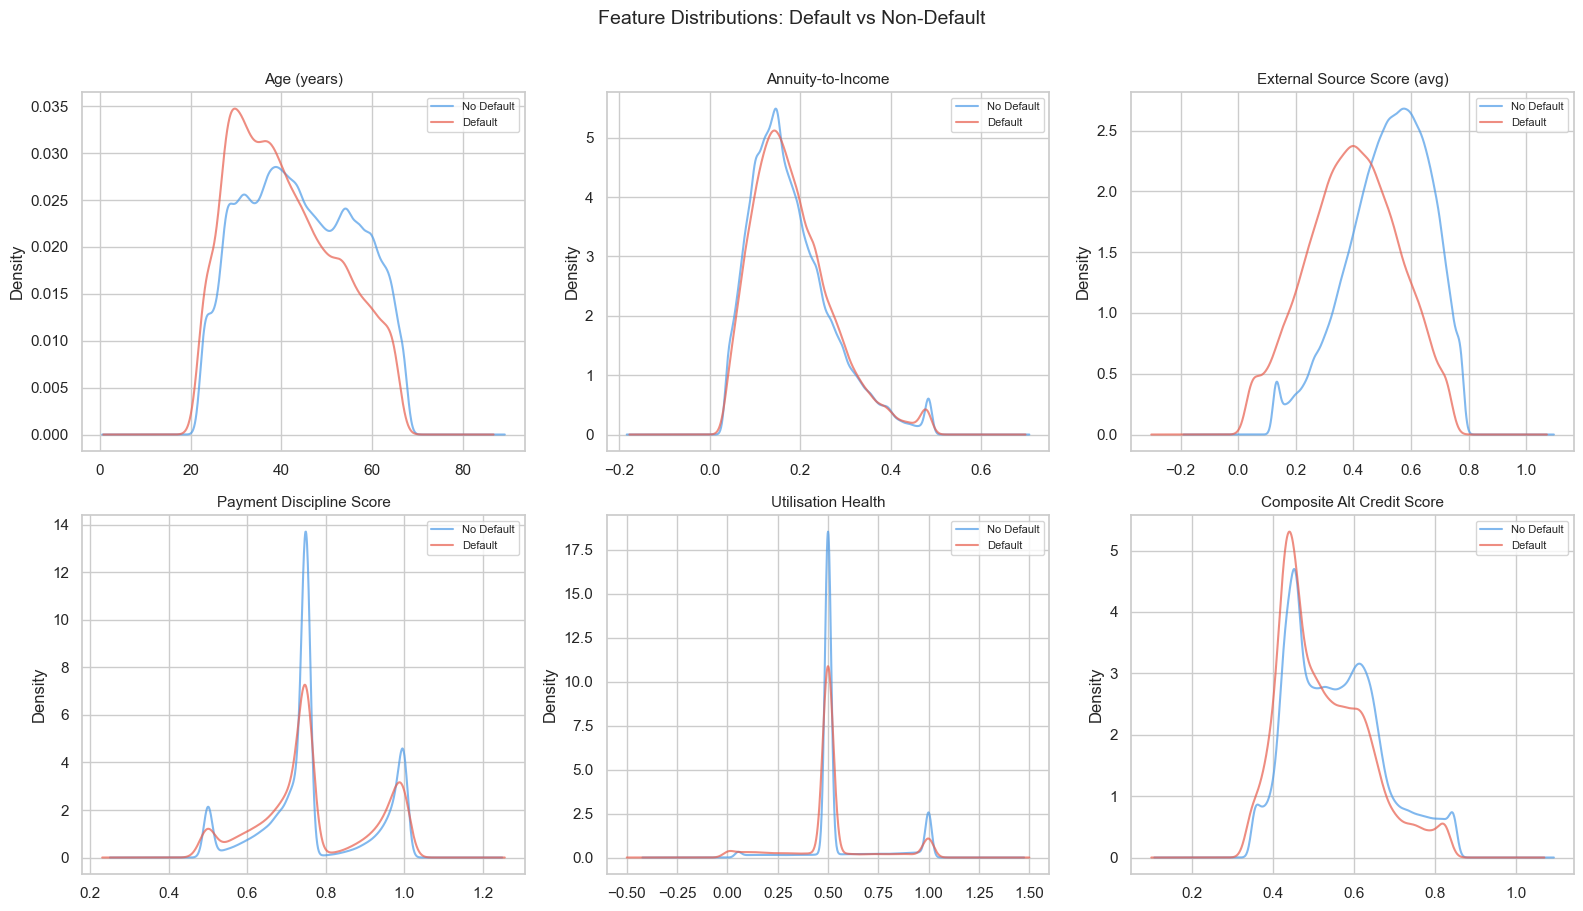

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_cols = [
    ("age_years",                "Age (years)"),
    ("annuity_to_income",        "Annuity-to-Income"),
    ("ext_source_mean",          "External Source Score (avg)"),
    ("payment_discipline_score", "Payment Discipline Score"),
    ("utilisation_health",       "Utilisation Health"),
    ("alt_credit_score",         "Composite Alt Credit Score"),
]

for ax, (col, label) in zip(axes, plot_cols):
    for t, color, name in [(0, "#4C9BE8", "No Default"), (1, "#E85D4C", "Default")]:
        vals = df.loc[df["TARGET"] == t, col].dropna()
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        vals.plot(kind="density", ax=ax, color=color, label=name, alpha=0.7)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions: Default vs Non-Default", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

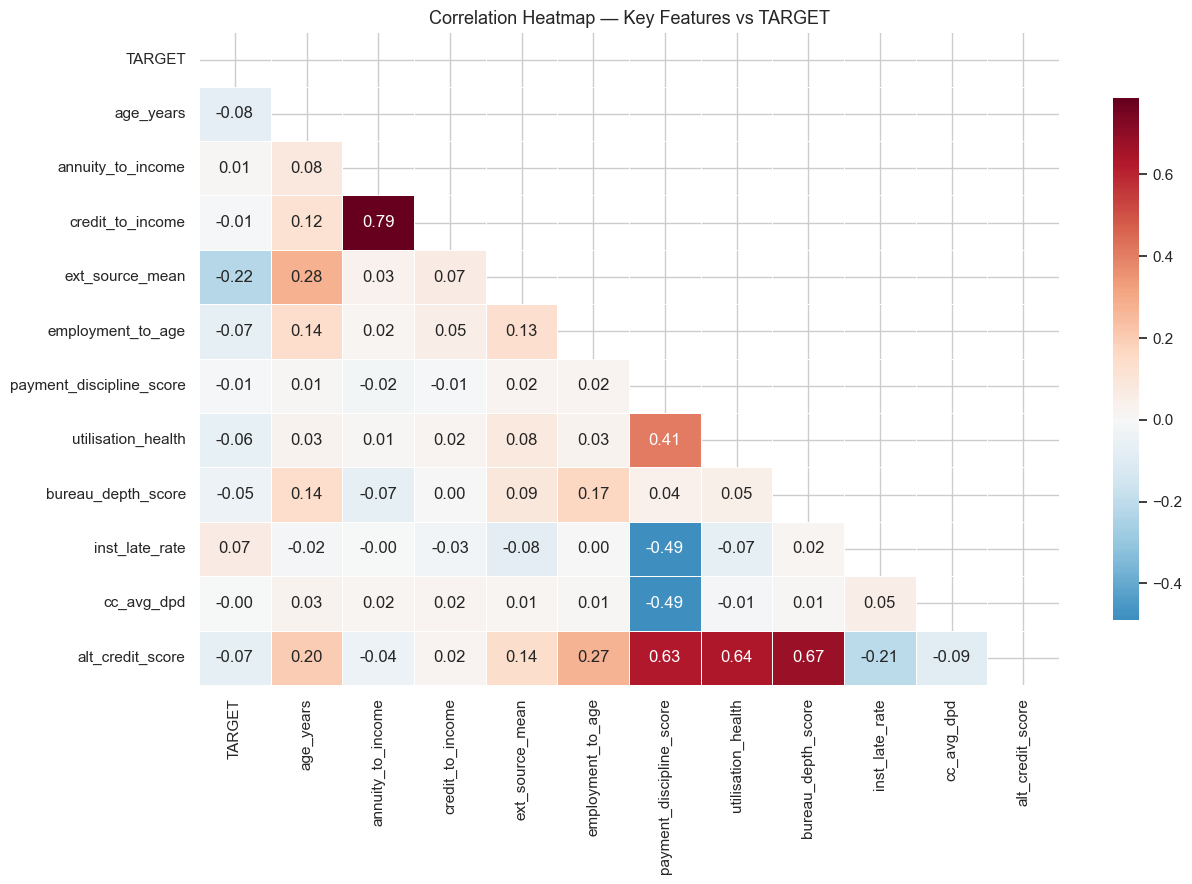

In [19]:
corr_cols = [
    "TARGET", "age_years", "annuity_to_income", "credit_to_income",
    "ext_source_mean", "employment_to_age", "payment_discipline_score",
    "utilisation_health", "bureau_depth_score", "inst_late_rate",
    "cc_avg_dpd", "alt_credit_score"
]

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(13, 9))
sns.heatmap(
    corr, mask=mask, cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", linewidths=0.4,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap — Key Features vs TARGET", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Preprocessing & Feature Selection

Steps in order:
1. Drop ID columns, `TARGET`, and protected attributes (gender, family status, organisation type)
2. Drop columns with more than 60% missing values
3. Label-encode remaining categoricals
4. Stratified 80/20 train/test split
5. K-fold smoothed target encoding for high-cardinality columns
6. Missing-indicator flags for features where absence carries signal
7. Inf → NaN sanitisation, then median imputation
8. Carve out a 10% calibration set from train (never touched by SMOTE or model training)
9. Variance threshold and high-correlation filtering on the full imputed training set
10. SMOTE on the model-training portion only

In [20]:
DROP_COLS = [
    "SK_ID_CURR", "TARGET",
    "CODE_GENDER",          
    "NAME_FAMILY_STATUS",    
    "ORGANIZATION_TYPE",     
]

DROP_COLS += doc_cols

high_miss = df.isnull().mean()
high_miss_cols = high_miss[high_miss > 0.6].index.tolist()
high_miss_cols = [c for c in high_miss_cols if c not in DROP_COLS]
print(f"Dropping {len(high_miss_cols)} columns with >60% missing")
DROP_COLS += high_miss_cols

feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f"Feature count : {len(feature_cols)}")

Dropping 64 columns with >60% missing
Feature count : 293


In [21]:
X_raw = df[feature_cols].copy()
y     = df["TARGET"].copy()

cat_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Categorical columns to encode: {len(cat_cols)}")

le = LabelEncoder()
for col in cat_cols:
    X_raw[col] = X_raw[col].astype(str)   
    X_raw[col] = le.fit_transform(X_raw[col])

print("Label encoding done ")
print(f"Final feature matrix shape: {X_raw.shape}")

Categorical columns to encode: 12
Label encoding done 
Final feature matrix shape: (307511, 293)


In [22]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}")
print(f"Train default rate: {y_train.mean():.3%}")
print(f"Test  default rate: {y_test.mean():.3%}")

Train: (246008, 293)  |  Test: (61503, 293)
Train default rate: 8.073%
Test  default rate: 8.073%


In [23]:
from sklearn.model_selection import KFold

def target_encode_kfold(df_train, df_test, col, target, n_splits=5, smoothing=10):
    global_mean = df_train[target].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    train_enc = np.zeros(len(df_train))
    for tr_idx, va_idx in kf.split(df_train):
        fold_stats = df_train.iloc[tr_idx].groupby(col)[target].agg(["mean","count"])
        fold_stats["smoothed"] = (
            (fold_stats["count"] * fold_stats["mean"] + smoothing * global_mean) /
            (fold_stats["count"] + smoothing)
        )
        train_enc[va_idx] = (
            df_train.iloc[va_idx][col]
            .map(fold_stats["smoothed"])
            .fillna(global_mean).values
        )
    full_stats = df_train.groupby(col)[target].agg(["mean","count"])
    full_stats["smoothed"] = (
        (full_stats["count"] * full_stats["mean"] + smoothing * global_mean) /
        (full_stats["count"] + smoothing)
    )
    test_enc = (
        df_test[col].map(full_stats["smoothed"]).fillna(global_mean).values
    )
    return train_enc, test_enc

TARGET_ENCODE_COLS = [
    "OCCUPATION_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_HOUSING_TYPE",
    "WEEKDAY_APPR_PROCESS_START",
    "HOUR_APPR_PROCESS_START",
    "NAME_EDUCATION_TYPE",     
    "NAME_CONTRACT_TYPE",       
]

train_idx = X_train_raw.index
test_idx  = X_test_raw.index
df_train_for_enc = df.loc[train_idx].copy()
df_test_for_enc  = df.loc[test_idx].copy()

for col in TARGET_ENCODE_COLS:
    if col in X_train_raw.columns:
        enc_col = f"{col}_te"
        tr_enc, te_enc = target_encode_kfold(
            df_train_for_enc, df_test_for_enc,
            col, "TARGET", n_splits=5, smoothing=10
        )
        X_train_raw[enc_col] = tr_enc
        X_test_raw[enc_col]  = te_enc
        print(f"Target encoded: {col} → {enc_col}")

print(f"\nTarget encoding done ")
print(f"Feature count after encoding: {X_train_raw.shape[1]}")

Target encoded: OCCUPATION_TYPE → OCCUPATION_TYPE_te
Target encoded: NAME_INCOME_TYPE → NAME_INCOME_TYPE_te
Target encoded: NAME_HOUSING_TYPE → NAME_HOUSING_TYPE_te
Target encoded: WEEKDAY_APPR_PROCESS_START → WEEKDAY_APPR_PROCESS_START_te
Target encoded: HOUR_APPR_PROCESS_START → HOUR_APPR_PROCESS_START_te
Target encoded: NAME_EDUCATION_TYPE → NAME_EDUCATION_TYPE_te
Target encoded: NAME_CONTRACT_TYPE → NAME_CONTRACT_TYPE_te

Target encoding done 
Feature count after encoding: 300


In [24]:
KEY_COLS_FOR_MISS_FLAG = [
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "AMT_GOODS_PRICE", "AMT_ANNUITY",
    "bureau_avg_overdue_days", "cc_avg_utilisation",
    "inst_avg_payment_ratio", "employment_years",
    "prev_avg_credit_amt",
    "bureau_loan_count",
    "pos_avg_dpd",
    "cc_months_observed",
    "inst_total_payments",
    "bbal_avg_status",
]
for col in KEY_COLS_FOR_MISS_FLAG:
    flag = f"{col}_nan"
    if col in X_train_raw.columns and flag not in X_train_raw.columns:
        X_train_raw[flag] = X_train_raw[col].isna().astype(int)
        X_test_raw[flag]  = X_test_raw[col].isna().astype(int)

feature_cols = list(X_train_raw.columns)

def sanitize_inf(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].clip(-3.4e38, 3.4e38)
    return df

X_train_raw = sanitize_inf(X_train_raw)
X_test_raw  = sanitize_inf(X_test_raw)

inf_train = np.isinf(X_train_raw.select_dtypes(include=[np.number]).values).sum()
inf_test  = np.isinf(X_test_raw.select_dtypes(include=[np.number]).values).sum()
print(f"Inf values remaining — train: {inf_train}, test: {inf_test}")

imputer     = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test_raw),      columns=feature_cols)

from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.001)
vt.fit(X_train_imp)
keep_mask    = vt.get_support()
removed_var  = [c for c, k in zip(feature_cols, keep_mask) if not k]
print(f"Near-zero variance features removed: {len(removed_var)}")

X_train_imp  = X_train_imp.loc[:, keep_mask]
X_test_imp   = X_test_imp.loc[:, keep_mask]
feature_cols = list(X_train_imp.columns)

corr_matrix = X_train_imp.corr().abs()
upper_tri   = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
target_corr = X_train_imp.corrwith(y_train.reset_index(drop=True)).abs()

to_drop_corr = []
for col in upper_tri.columns:
    correlated_with = upper_tri.index[upper_tri[col] > 0.90].tolist()
    for paired_col in correlated_with:
        drop = col if target_corr.get(col, 0) < target_corr.get(paired_col, 0) else paired_col
        if drop not in to_drop_corr:
            to_drop_corr.append(drop)

print(f"Highly correlated features removed: {len(to_drop_corr)}")
X_train_imp  = X_train_imp.drop(columns=to_drop_corr, errors="ignore")
X_test_imp   = X_test_imp.drop(columns=to_drop_corr, errors="ignore")
feature_cols = list(X_train_imp.columns)
print(f"Final feature count after selection: {len(feature_cols)}")

X_train_model, X_calib, y_train_model, y_calib = train_test_split(
    X_train_imp, y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=RANDOM_STATE
)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_model, y_train_model)

scale_pos_weight = (y_train_model == 0).sum() / (y_train_model == 1).sum()

X_calib = X_calib.reindex(columns=feature_cols, fill_value=np.nan)

print(f"SMOTE train  : {X_train_sm.shape}   | Default rate: {y_train_sm.mean():.3%}")
print(f"Train (raw)  : {X_train_model.shape} | Default rate: {y_train_model.mean():.3%}")
print(f"Calibration  : {X_calib.shape}       | Default rate: {y_calib.mean():.3%}")
print(f"Test         : {X_test_imp.shape}     | Default rate: {y_test.mean():.3%}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"Final feature count: {len(feature_cols)}")

Inf values remaining — train: 0, test: 0
Near-zero variance features removed: 15
Highly correlated features removed: 93
Final feature count after selection: 204
SMOTE train  : (407066, 204)   | Default rate: 50.000%
Train (raw)  : (221407, 204) | Default rate: 8.073%
Calibration  : (24601, 204)       | Default rate: 8.073%
Test         : (61503, 204)     | Default rate: 8.073%
scale_pos_weight: 11.39
Final feature count: 204


## 8. Model Training

Four model families, in order of complexity:

| Model | Training set | Imbalance handling |
|---|---|---|
| Logistic Regression | SMOTE-balanced | Via SMOTE |
| Random Forest | SMOTE-balanced | `balanced_subsample` |
| XGBoost | Raw imbalanced | `scale_pos_weight` |
| LightGBM | Raw imbalanced | `sample_weight` (balanced) |

Early stopping for tree models uses an internal 15% validation split — the held-out test set is never seen during training or tuning. After finding the best iteration, each tree model is retrained on 100% of the training data with that fixed count.

In [27]:
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Model"     : name,
        "AUC-ROC"   : roc_auc_score(y_true, y_prob),
        "Avg Prec"  : average_precision_score(y_true, y_prob),
        "Accuracy"  : accuracy_score(y_true, y_pred),
        "Precision" : precision_score(y_true, y_pred, zero_division=0),
        "Recall"    : recall_score(y_true, y_pred, zero_division=0),
        "F1"        : f1_score(y_true, y_pred, zero_division=0),
    }

results = []
probs   = {}

In [28]:
KEY_COLS_FOR_MISS_FLAG = [
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "AMT_GOODS_PRICE", "AMT_ANNUITY",
    "bureau_avg_overdue_days", "cc_avg_utilisation",
    "inst_avg_payment_ratio", "employment_years",
    "prev_avg_credit_amt",       
    "bureau_loan_count",         
    "pos_avg_dpd",               
    "cc_months_observed",        
    "inst_total_payments",       
    "bbal_avg_status",           
]
for col in KEY_COLS_FOR_MISS_FLAG:
    flag = f"{col}_nan"
    if col in X_train_raw.columns and flag not in X_train_raw.columns:
        X_train_raw[flag] = X_train_raw[col].isna().astype(int)
        X_test_raw[flag]  = X_test_raw[col].isna().astype(int)

feature_cols = list(X_train_raw.columns)

def sanitize_inf(df):
    """Replace inf/-inf with NaN and clip extreme float values."""
    df = df.replace([np.inf, -np.inf], np.nan)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].clip(-3.4e38, 3.4e38)
    return df

X_train_raw = sanitize_inf(X_train_raw)
X_test_raw  = sanitize_inf(X_test_raw)

inf_train = np.isinf(X_train_raw.select_dtypes(include=[np.number]).values).sum()
inf_test  = np.isinf(X_test_raw.select_dtypes(include=[np.number]).values).sum()
print(f"Inf values remaining — train: {inf_train}, test: {inf_test}")

imputer     = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test_raw),      columns=feature_cols)

X_train_model, X_calib, y_train_model, y_calib = train_test_split(
    X_train_imp, y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=RANDOM_STATE
)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_model, y_train_model)

X_train_xgb = X_train_model.copy()
y_train_xgb = y_train_model.copy()

scale_pos_weight = (y_train_model == 0).sum() / (y_train_model == 1).sum()

print(f"SMOTE train  : {X_train_sm.shape}   | Default rate: {y_train_sm.mean():.3%}")
print(f"XGB/LGB train: {X_train_xgb.shape}  | Default rate: {y_train_xgb.mean():.3%}")
print(f"Calibration  : {X_calib.shape}       | Default rate: {y_calib.mean():.3%}")
print(f"Test         : {X_test_imp.shape}     | Default rate: {y_test.mean():.3%}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"Final feature count: {len(feature_cols)}")

from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.001)
vt.fit(X_train_imp)
keep_mask     = vt.get_support()
removed_var   = [c for c, k in zip(feature_cols, keep_mask) if not k]
print(f"Near-zero variance features removed: {len(removed_var)}")

X_train_imp   = X_train_imp.loc[:, keep_mask]
X_test_imp    = X_test_imp.loc[:, keep_mask]
feature_cols  = list(X_train_imp.columns)

corr_matrix = X_train_imp.corr().abs()
upper_tri   = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
target_corr = X_train_imp.corrwith(y_train.reset_index(drop=True)).abs()

to_drop_corr = []
for col in upper_tri.columns:
    correlated_with = upper_tri.index[upper_tri[col] > 0.90].tolist()
    for paired_col in correlated_with:
        drop = col if target_corr.get(col, 0) < target_corr.get(paired_col, 0) else paired_col
        if drop not in to_drop_corr:
            to_drop_corr.append(drop)

print(f"Highly correlated features removed: {len(to_drop_corr)}")
X_train_imp  = X_train_imp.drop(columns=to_drop_corr, errors="ignore")
X_test_imp   = X_test_imp.drop(columns=to_drop_corr, errors="ignore")
feature_cols = list(X_train_imp.columns)

print(f"Final feature count after selection: {len(feature_cols)}")

X_calib       = X_calib.reindex(columns=feature_cols, fill_value=np.nan)
X_train_model = X_train_imp.copy()   # already filtered — use as-is

print(f"X_calib realigned to {len(feature_cols)} features ")

Inf values remaining — train: 0, test: 0
SMOTE train  : (407066, 312)   | Default rate: 50.000%
XGB/LGB train: (221407, 312)  | Default rate: 8.073%
Calibration  : (24601, 312)       | Default rate: 8.073%
Test         : (61503, 312)     | Default rate: 8.073%
scale_pos_weight: 11.39
Final feature count: 312
Near-zero variance features removed: 15
Highly correlated features removed: 93
Final feature count after selection: 204
X_calib realigned to 204 features 


### 8a. Logistic Regression

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

X_train_sm_scaled = scaler.transform(X_train_sm[feature_cols])

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    C=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lr.fit(X_train_sm_scaled, y_train_sm)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

probs["Logistic Regression"] = lr_probs
results.append(evaluate_model("Logistic Regression", y_test, lr_probs))

print(f"LR AUC: {roc_auc_score(y_test, lr_probs):.4f}")

LR AUC: 0.7677


### 8b. Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

X_train_rf = X_train_sm[feature_cols]
X_test_rf  = X_test_imp[feature_cols]

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train_rf, y_train_sm)

rf_probs = rf.predict_proba(X_test_rf)[:, 1]

probs["Random Forest"] = rf_probs
results.append(evaluate_model("Random Forest", y_test, rf_probs))

print(f"RF AUC: {roc_auc_score(y_test, rf_probs):.4f}")

RF AUC: 0.7387


### 8c. XGBoost — baseline then Optuna tuning

Early stopping runs on an 85/15 internal split to find the best iteration count. The final model is then retrained on the full training set with that fixed count.

In [31]:
X_xgb_tr, X_xgb_va, y_xgb_tr, y_xgb_va = train_test_split(
    X_train_imp, y_train,
    test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)

xgb_model = XGBClassifier(
    n_estimators        = 3000,
    max_depth           = 6,
    learning_rate       = 0.03,
    subsample           = 0.80,
    colsample_bytree    = 0.80,
    colsample_bylevel   = 0.80,
    colsample_bynode    = 0.80,
    min_child_weight    = 10,
    gamma               = 1.0,
    reg_alpha           = 0.1,
    reg_lambda          = 2.0,
    max_delta_step      = 1,
    scale_pos_weight    = scale_pos_weight,
    tree_method         = "hist",
    eval_metric         = "auc",
    early_stopping_rounds = 75,
    random_state        = RANDOM_STATE,
    n_jobs              = -1,
)

xgb_model.fit(
    X_xgb_tr, y_xgb_tr,
    eval_set=[(X_xgb_va, y_xgb_va)],   
    verbose=200
)

best_iter = xgb_model.best_iteration
print(f"Best iteration from early stopping: {best_iter}")

xgb_model_full = XGBClassifier(
    n_estimators        = best_iter + 1,  
    max_depth           = 6,
    learning_rate       = 0.03,
    subsample           = 0.80,
    colsample_bytree    = 0.80,
    colsample_bylevel   = 0.80,
    colsample_bynode    = 0.80,
    min_child_weight    = 10,
    gamma               = 1.0,
    reg_alpha           = 0.1,
    reg_lambda          = 2.0,
    max_delta_step      = 1,
    scale_pos_weight    = scale_pos_weight,
    tree_method         = "hist",
    random_state        = RANDOM_STATE,
    n_jobs              = -1,
)
xgb_model_full.fit(X_train_imp, y_train)  

xgb_probs = xgb_model_full.predict_proba(X_test_imp)[:, 1]

probs["XGBoost"] = xgb_probs
results.append(evaluate_model("XGBoost", y_test, xgb_probs))
print(f"\nXGB AUC: {roc_auc_score(y_test, xgb_probs):.4f}")

[0]	validation_0-auc:0.72252
[200]	validation_0-auc:0.77201
[400]	validation_0-auc:0.77734
[600]	validation_0-auc:0.77849
[697]	validation_0-auc:0.77832
Best iteration from early stopping: 622

XGB AUC: 0.7823


In [32]:
if OPTUNA_OK:
    from optuna.pruners import MedianPruner
    from optuna.samplers import TPESampler

    OPTUNA_ROW_SAMPLE = 50_000
    rng        = np.random.RandomState(RANDOM_STATE)
    idx_sample = rng.choice(len(X_train_imp), size=OPTUNA_ROW_SAMPLE, replace=False)
    X_opt = X_train_imp.iloc[idx_sample].reset_index(drop=True)
    y_opt = y_train.iloc[idx_sample].reset_index(drop=True)

    skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    def xgb_objective(trial):
        grow_policy = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

        params = {
            "n_estimators"        : 700,
            "grow_policy"         : grow_policy,
            "max_depth"           : trial.suggest_int("max_depth", 4, 8) if grow_policy == "depthwise" else 0,
            "max_leaves"          : trial.suggest_int("max_leaves", 31, 256) if grow_policy == "lossguide" else 0,
            "learning_rate"       : trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
            "subsample"           : trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree"    : trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "colsample_bylevel"   : trial.suggest_float("colsample_bylevel", 0.5, 1.0),
            "colsample_bynode"    : trial.suggest_float("colsample_bynode", 0.5, 1.0),
            "min_child_weight"    : trial.suggest_int("min_child_weight", 5, 60),
            "gamma"               : trial.suggest_float("gamma", 0.0, 3.0),
            "reg_alpha"           : trial.suggest_float("reg_alpha", 1e-3, 15.0, log=True),
            "reg_lambda"          : trial.suggest_float("reg_lambda", 1e-3, 15.0, log=True),
            "max_delta_step"      : trial.suggest_int("max_delta_step", 0, 5),
            "scale_pos_weight"    : scale_pos_weight,
            "tree_method"         : "hist",
            "eval_metric"         : "auc",
            "early_stopping_rounds": 40,
            "random_state"        : RANDOM_STATE,
            "n_jobs"              : -1,
        }

        fold_aucs = []
        for fold_idx, (tr_idx, va_idx) in enumerate(skf_opt.split(X_opt, y_opt)):
            X_tr, X_va = X_opt.iloc[tr_idx], X_opt.iloc[va_idx]
            y_tr, y_va = y_opt.iloc[tr_idx], y_opt.iloc[va_idx]
            m = XGBClassifier(**params)
            m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            fold_aucs.append(roc_auc_score(y_va, m.predict_proba(X_va)[:, 1]))
            trial.report(np.mean(fold_aucs), fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return np.mean(fold_aucs)

    xgb_study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE, multivariate=True, n_startup_trials=10),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1)
    )

    xgb_study.enqueue_trial({
        "grow_policy": "depthwise", "max_depth": 6, "max_leaves": 0,
        "learning_rate": 0.03, "subsample": 0.80, "colsample_bytree": 0.80,
        "colsample_bylevel": 0.80, "colsample_bynode": 0.80,
        "min_child_weight": 10, "gamma": 1.0,
        "reg_alpha": 0.1, "reg_lambda": 2.0, "max_delta_step": 1,
    })
    xgb_study.enqueue_trial({
        "grow_policy": "lossguide", "max_depth": 0, "max_leaves": 127,
        "learning_rate": 0.04, "subsample": 0.80, "colsample_bytree": 0.75,
        "colsample_bylevel": 0.70, "colsample_bynode": 0.70,
        "min_child_weight": 15, "gamma": 0.5,
        "reg_alpha": 0.3, "reg_lambda": 1.5, "max_delta_step": 1,
    })
    xgb_study.enqueue_trial({
        "grow_policy": "lossguide", "max_depth": 0, "max_leaves": 255,
        "learning_rate": 0.03, "subsample": 0.75, "colsample_bytree": 0.70,
        "colsample_bylevel": 0.65, "colsample_bynode": 0.65,
        "min_child_weight": 20, "gamma": 1.5,
        "reg_alpha": 1.0, "reg_lambda": 3.0, "max_delta_step": 2,
    })

    xgb_study.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

    print(f"\nBest CV AUC (Optuna): {xgb_study.best_value:.4f}")
    print(f"Base XGB test AUC  : {roc_auc_score(y_test, xgb_probs):.4f}")
    print(f"Best grow_policy   : {xgb_study.best_params.get('grow_policy')}")
    print(f"Best params: {xgb_study.best_params}")

    best_params = xgb_study.best_params.copy()
    best_params.pop("early_stopping_rounds", None)

    X_xgb_tr2, X_xgb_va2, y_xgb_tr2, y_xgb_va2 = train_test_split(
        X_train_imp, y_train,
        test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
    )
    best_xgb_es = XGBClassifier(
        **best_params,
        n_estimators          = 3000,
        scale_pos_weight      = scale_pos_weight,
        tree_method           = "hist",
        eval_metric           = "auc",
        early_stopping_rounds = 100,
        random_state          = RANDOM_STATE,
        n_jobs                = -1,
    )
    best_xgb_es.fit(X_xgb_tr2, y_xgb_tr2,
                    eval_set=[(X_xgb_va2, y_xgb_va2)], verbose=200)
    tuned_best_iter = best_xgb_es.best_iteration
    print(f"Tuned XGB best iteration: {tuned_best_iter}")

    final_xgb_model = XGBClassifier(
        **best_params,
        n_estimators     = tuned_best_iter + 1,
        scale_pos_weight = scale_pos_weight,
        tree_method      = "hist",
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
    )
    final_xgb_model.fit(X_train_imp, y_train)

    final_xgb_probs = final_xgb_model.predict_proba(X_test_imp)[:, 1]
    final_xgb_auc   = roc_auc_score(y_test, final_xgb_probs)

    if final_xgb_auc > roc_auc_score(y_test, xgb_probs):
        print(f"\nXGB tuned AUC: {final_xgb_auc:.4f}  IMPROVED by +{final_xgb_auc - roc_auc_score(y_test, xgb_probs):.4f}")
    else:
        print(f"\nXGB tuned AUC: {final_xgb_auc:.4f}  — keeping base, which was {roc_auc_score(y_test, xgb_probs):.4f}")
        final_xgb_model = xgb_model_full
        final_xgb_probs = xgb_probs

    probs["XGBoost (tuned)"] = final_xgb_probs
    results.append(evaluate_model("XGBoost (tuned)", y_test, final_xgb_probs))

else:
    final_xgb_model = xgb_model_full
    final_xgb_probs = xgb_probs
    print("Optuna not installed — using base XGBoost")



  0%|          | 0/40 [00:00<?, ?it/s]

[W 2026-04-25 23:17:02,636] The parameter `max_depth` in Trial#10 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2026-04-25 23:17:21,669] The parameter `max_leaves` in Trial#11 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2026-04-25 23:17:55,924] The parameter `max_depth` in Trial#12 is sampled independently using `Ran

### 8d. LightGBM — 5-fold CV with feature selection

An early-stopping run determines the best iteration and feature importances. The bottom 15% of features by importance are dropped. 5-fold CV gives an unbiased OOF AUC estimate. The final model trains on the full selected feature set.

In [33]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold

skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_lgb_base_tr, X_lgb_base_va, y_lgb_base_tr, y_lgb_base_va = train_test_split(
    X_train_imp, y_train,
    test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)

lgbm_es = LGBMClassifier(
    n_estimators      = 5000,
    learning_rate     = 0.03,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 50,
    min_split_gain    = 0.01,   
    subsample         = 0.80,
    subsample_freq    = 1,
    colsample_bytree  = 0.80,
    reg_alpha         = 0.1,
    reg_lambda        = 2.0,
    n_jobs            = -1,
    random_state      = RANDOM_STATE,
    verbose           = -1,
)
lgbm_es.fit(
    X_lgb_base_tr, y_lgb_base_tr,
    sample_weight = compute_sample_weight("balanced", y_lgb_base_tr),
    eval_set      = [(X_lgb_base_va, y_lgb_base_va)],
    eval_metric   = "auc",
    callbacks     = [
        lgb.early_stopping(stopping_rounds=100, verbose=True, first_metric_only=True),
        lgb.log_evaluation(period=300),
    ],
)
lgbm_best_iter = lgbm_es.best_iteration_
print(f"Best iteration from early stopping: {lgbm_best_iter}")

importances       = pd.Series(lgbm_es.feature_importances_, index=X_train_imp.columns)
keep_threshold    = importances.quantile(0.15)
selected_features = importances[importances > keep_threshold].index.tolist()
dropped_features  = importances[importances <= keep_threshold].index.tolist()
print(f"\nFeature selection: kept {len(selected_features)} / {len(X_train_imp.columns)}")
print(f"Dropped {len(dropped_features)} low-importance features")

X_train_sel = X_train_imp[selected_features]
X_test_sel  = X_test_imp[selected_features]

print("\nRunning 5-Fold CV...")
oof_lgb = np.zeros(len(X_train_sel))
cv_aucs = []

for fold, (tr_idx, va_idx) in enumerate(skf_cv.split(X_train_sel, y_train)):
    X_tr, X_va = X_train_sel.iloc[tr_idx], X_train_sel.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx],     y_train.iloc[va_idx]

    fold_model = LGBMClassifier(
        n_estimators      = lgbm_best_iter,
        learning_rate     = 0.03,
        num_leaves        = 127,
        max_depth         = -1,
        min_child_samples = 50,
        min_split_gain    = 0.01,
        subsample         = 0.80,
        subsample_freq    = 1,
        colsample_bytree  = 0.80,
        reg_alpha         = 0.1,
        reg_lambda        = 2.0,
        n_jobs            = -1,
        random_state      = RANDOM_STATE,
        verbose           = -1,
    )
    fold_model.fit(X_tr, y_tr, sample_weight=compute_sample_weight("balanced", y_tr))
    fold_preds      = fold_model.predict_proba(X_va)[:, 1]
    oof_lgb[va_idx] = fold_preds
    fold_auc        = roc_auc_score(y_va, fold_preds)
    cv_aucs.append(fold_auc)
    print(f"  Fold {fold+1}/5  AUC = {fold_auc:.4f}")

cv_mean = np.mean(cv_aucs)
cv_std  = np.std(cv_aucs)
oof_auc = roc_auc_score(y_train, oof_lgb)
print(f"\n5-Fold CV AUC : {cv_mean:.4f} ± {cv_std:.4f}")
print(f"OOF AUC       : {oof_auc:.4f}  ← most reliable number to report")

lgbm_model = LGBMClassifier(
    n_estimators      = lgbm_best_iter,
    learning_rate     = 0.03,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 50,
    min_split_gain    = 0.01,
    subsample         = 0.80,
    subsample_freq    = 1,
    colsample_bytree  = 0.80,
    reg_alpha         = 0.1,
    reg_lambda        = 2.0,
    n_jobs            = -1,
    random_state      = RANDOM_STATE,
    verbose           = -1,
)
lgbm_model.fit(
    X_train_sel, y_train,
    sample_weight=compute_sample_weight("balanced", y_train),
)

lgbm_probs = lgbm_model.predict_proba(X_test_sel)[:, 1]
test_auc   = roc_auc_score(y_test, lgbm_probs)

probs["LightGBM"] = lgbm_probs
results.append(evaluate_model("LightGBM", y_test, lgbm_probs))

print(f"\nTest AUC : {test_auc:.4f}")
print(f"OOF AUC  : {oof_auc:.4f}")
print(f"Gap      : {abs(test_auc - oof_auc):.4f}  {' check for overfit' if abs(test_auc - oof_auc) > 0.01 else ' consistent'}")

lgb_tuned2       = lgbm_model
lgb_tuned2_probs = lgbm_probs
lgbm_dart_probs  = lgbm_probs   

Training until validation scores don't improve for 100 rounds
[300]	valid_0's auc: 0.776543	valid_0's binary_logloss: 0.469476
Early stopping, best iteration is:
[339]	valid_0's auc: 0.77692	valid_0's binary_logloss: 0.459352
Evaluated only: auc
Best iteration from early stopping: 339

Feature selection: kept 172 / 204
Dropped 32 low-importance features

Running 5-Fold CV...
  Fold 1/5  AUC = 0.7741
  Fold 2/5  AUC = 0.7780
  Fold 3/5  AUC = 0.7782
  Fold 4/5  AUC = 0.7789
  Fold 5/5  AUC = 0.7774

5-Fold CV AUC : 0.7773 ± 0.0017
OOF AUC       : 0.7773  ← most reliable number to report

Test AUC : 0.7828
OOF AUC  : 0.7773
Gap      : 0.0055   consistent


### 8e. LightGBM — Optuna tuning

In [ ]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_ROW_SAMPLE_LGB = 100_000   
rng_lgb   = np.random.RandomState(RANDOM_STATE)
idx_lgb   = rng_lgb.choice(len(X_train_sel), size=min(OPTUNA_ROW_SAMPLE_LGB, len(X_train_sel)), replace=False)
X_lgb_opt = X_train_sel.iloc[idx_lgb].reset_index(drop=True)
y_lgb_opt = y_train.iloc[idx_lgb].reset_index(drop=True)

def lgb_objective(trial):
    params = {
        "objective":              "binary",
        "metric":                 "auc",
        "verbosity":              -1,
        "boosting_type":          "gbdt",
        "n_estimators":           2000,      
        "num_leaves":             trial.suggest_int("num_leaves", 128, 400),
        "max_depth":              trial.suggest_int("max_depth", 6, 12),
        "min_child_samples":      trial.suggest_int("min_child_samples", 20, 120),
        "reg_alpha":              trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda":             trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "min_split_gain":         trial.suggest_float("min_split_gain", 0.0, 0.5),  
        "learning_rate":          trial.suggest_float("learning_rate", 0.01, 0.06, log=True),
        "subsample":              trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq":         1,
        "colsample_bytree":       trial.suggest_float("colsample_bytree", 0.55, 1.0),  
        "feature_fraction_bynode": trial.suggest_float("feature_fraction_bynode", 0.5, 1.0),
        "path_smooth":            trial.suggest_float("path_smooth", 0.0, 1.0), 
        "n_jobs":                 -1,
        "random_state":           RANDOM_STATE,
    }

    cv   = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    aucs = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_lgb_opt, y_lgb_opt)):
        Xtr, Xval = X_lgb_opt.iloc[tr_idx],  X_lgb_opt.iloc[val_idx]
        ytr, yval = y_lgb_opt.iloc[tr_idx],  y_lgb_opt.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            Xtr, ytr,
            sample_weight = compute_sample_weight("balanced", ytr),
            eval_set      = [(Xval, yval)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=75, verbose=False, first_metric_only=True),
                lgb.log_evaluation(period=0),
            ],
        )
        aucs.append(roc_auc_score(yval, model.predict_proba(Xval)[:, 1]))
        trial.report(np.mean(aucs), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(aucs)

study_lgb = optuna.create_study(
    direction = "maximize",
    sampler   = TPESampler(seed=RANDOM_STATE, multivariate=True, n_startup_trials=10),
    pruner    = MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)

study_lgb.enqueue_trial({
    "num_leaves": 255, "max_depth": 9, "min_child_samples": 30,
    "reg_alpha": 0.05, "reg_lambda": 1.0, "min_split_gain": 0.01,
    "learning_rate": 0.015, "subsample": 0.75, "colsample_bytree": 0.75,
    "feature_fraction_bynode": 0.80, "path_smooth": 0.0,
})
study_lgb.enqueue_trial({
    "num_leaves": 320, "max_depth": 10, "min_child_samples": 40,
    "reg_alpha": 0.1, "reg_lambda": 0.5, "min_split_gain": 0.02,
    "learning_rate": 0.02, "subsample": 0.80, "colsample_bytree": 0.70,
    "feature_fraction_bynode": 0.75, "path_smooth": 0.1,
})
study_lgb.enqueue_trial({
    "num_leaves": 200, "max_depth": 11, "min_child_samples": 60,
    "reg_alpha": 0.5, "reg_lambda": 2.0, "min_split_gain": 0.05,
    "learning_rate": 0.012, "subsample": 0.70, "colsample_bytree": 0.65,
    "feature_fraction_bynode": 0.70, "path_smooth": 0.5,
})

study_lgb.optimize(lgb_objective, n_trials=40, show_progress_bar=True)

print(f"\nBest LGB CV AUC (Optuna): {study_lgb.best_value:.4f}")
print(f"Base LGB test AUC      : {roc_auc_score(y_test, lgbm_probs):.4f}")
print(f"Best params: {study_lgb.best_params}")

best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({
    "objective": "binary", "metric": "auc", "verbosity": -1,
    "boosting_type": "gbdt", "n_estimators": 8000,
    "subsample_freq": 1, "n_jobs": -1, "random_state": RANDOM_STATE,
})

X_lgb_tr2, X_lgb_va2, y_lgb_tr2, y_lgb_va2 = train_test_split(
    X_train_sel, y_train,
    test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)

lgb_tuned_es = lgb.LGBMClassifier(**best_lgb_params)
lgb_tuned_es.fit(
    X_lgb_tr2, y_lgb_tr2,
    sample_weight = compute_sample_weight("balanced", y_lgb_tr2),  
    eval_set      = [(X_lgb_va2, y_lgb_va2)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, verbose=True, first_metric_only=True),
        lgb.log_evaluation(period=200),
    ],
)
tuned_best_iter = lgb_tuned_es.best_iteration_
print(f"Tuned LGB best iteration: {tuned_best_iter}")

best_lgb_params_full = best_lgb_params.copy()
best_lgb_params_full["n_estimators"] = tuned_best_iter + 1

lgb_tuned2 = lgb.LGBMClassifier(**best_lgb_params_full)
lgb_tuned2.fit(
    X_train_sel, y_train,
    sample_weight = compute_sample_weight("balanced", y_train),
)

lgb_tuned2_probs = lgb_tuned2.predict_proba(X_test_sel)[:, 1]
lgb_tuned2_auc   = roc_auc_score(y_test, lgb_tuned2_probs)
base_lgb_auc     = roc_auc_score(y_test, lgbm_probs)

print(f"\nLGB tuned AUC : {lgb_tuned2_auc:.4f}  (improvement: {lgb_tuned2_auc - base_lgb_auc:+.4f})")

if lgb_tuned2_auc > base_lgb_auc:
    probs["LightGBM (tuned)"] = lgb_tuned2_probs
    results.append(evaluate_model("LightGBM (tuned)", y_test, lgb_tuned2_probs))
else:
    print("Tuned LGB did not improve — using base GBDT for ensemble")
    lgb_tuned2       = lgbm_model
    lgb_tuned2_probs = lgbm_probs
    probs["LightGBM (tuned)"] = lgbm_probs
    results.append(evaluate_model("LightGBM (tuned)", y_test, lgbm_probs))++++

  0%|          | 0/40 [00:00<?, ?it/s]


Best LGB CV AUC (Optuna): 0.7725
Base LGB test AUC      : 0.7828
Best params: {'num_leaves': 208, 'max_depth': 12, 'min_child_samples': 112, 'reg_alpha': 2.465799755284907, 'reg_lambda': 0.019731467916938954, 'min_split_gain': 0.40216391542548124, 'learning_rate': 0.010121214703989925, 'subsample': 0.802912537033431, 'colsample_bytree': 0.6489619026651425, 'feature_fraction_bynode': 0.592426027697827, 'path_smooth': 0.4888689764415405}
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.76469
[400]	valid_0's auc: 0.773097
[600]	valid_0's auc: 0.776889
[800]	valid_0's auc: 0.778161
[1000]	valid_0's auc: 0.778778
[1200]	valid_0's auc: 0.778785
Early stopping, best iteration is:
[1092]	valid_0's auc: 0.77901
Evaluated only: auc
Tuned LGB best iteration: 1092

LGB tuned AUC : 0.7844  (improvement: +0.0017)


### 8f. CatBoost

In [35]:
try:
    from catboost import CatBoostClassifier

    cb_model = CatBoostClassifier(
        iterations       = 2000,
        learning_rate    = 0.03,
        depth            = 6,
        l2_leaf_reg      = 3.0,
        subsample        = 0.80,
        colsample_bylevel= 0.80,
        scale_pos_weight = scale_pos_weight,
        eval_metric      = "AUC",
        early_stopping_rounds = 100,
        random_seed      = RANDOM_STATE,
        verbose          = 200,
    )

    X_cb_tr, X_cb_va, y_cb_tr, y_cb_va = train_test_split(
        X_train_sel, y_train,
        test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
    )

    cb_model.fit(X_cb_tr, y_cb_tr, eval_set=(X_cb_va, y_cb_va))

    cb_probs = cb_model.predict_proba(X_test_sel)[:, 1]
    probs["CatBoost"] = cb_probs
    results.append(evaluate_model("CatBoost", y_test, cb_probs))
    print(f"CatBoost AUC: {roc_auc_score(y_test, cb_probs):.4f}")
    CATBOOST_OK = True

except ImportError:
    print("CatBoost not installed — pip install catboost")
    CATBOOST_OK = False

0:	test: 0.7200407	best: 0.7200407 (0)	total: 229ms	remaining: 7m 37s
200:	test: 0.7633549	best: 0.7633549 (200)	total: 13.7s	remaining: 2m 2s
400:	test: 0.7711065	best: 0.7711263 (399)	total: 26.1s	remaining: 1m 44s
600:	test: 0.7754002	best: 0.7754055 (599)	total: 38.3s	remaining: 1m 29s
800:	test: 0.7769326	best: 0.7769372 (791)	total: 50.4s	remaining: 1m 15s
1000:	test: 0.7774963	best: 0.7775855 (956)	total: 1m 2s	remaining: 1m 2s
1200:	test: 0.7779108	best: 0.7779379 (1199)	total: 1m 14s	remaining: 49.5s
1400:	test: 0.7779592	best: 0.7781504 (1377)	total: 1m 26s	remaining: 37s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7781504105
bestIteration = 1377

Shrink model to first 1378 iterations.
CatBoost AUC: 0.7836


### 8g. Ensemble — OOF stacking, rank averaging, weighted average

OOF predictions from each base model train a logistic regression meta-learner. Three blending strategies are compared — stacking, rank averaging, and manual weighted average — and the best is selected as `final_ensemble_probs`.

In [36]:
from scipy.stats import rankdata
from sklearn.base import clone

def rank_avg(prob_arrays):
    n = len(prob_arrays[0])
    return np.column_stack([rankdata(p) / n for p in prob_arrays]).mean(axis=1)

X_train_sel = X_train_sel.reset_index(drop=True)
X_train_imp = X_train_imp.reset_index(drop=True)
y_train     = y_train.reset_index(drop=True)

base_models = {
    "xgb_tuned":  (final_xgb_model,  X_test_imp),
    "lgb_gbdt":   (lgbm_model,        X_test_sel),
    "lgb_tuned":  (lgb_tuned2,        X_test_sel),
}
if CATBOOST_OK:
    base_models["catboost"] = (cb_model, X_test_sel)

test_preds = {}
print("Test AUCs:")
for name, (mdl, X_te) in base_models.items():
    p = mdl.predict_proba(X_te)[:, 1]
    test_preds[name] = p
    print(f"  {name:20s}: {roc_auc_score(y_test, p):.4f}")

skf_oof   = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_preds = {name: np.zeros(len(X_train_sel)) for name in base_models}

print("\nGenerating OOF predictions...")
for fold, (tr_idx, va_idx) in enumerate(skf_oof.split(X_train_sel, y_train)):
    print(f"  Fold {fold+1}/5", end=" ", flush=True)
    y_tr = y_train.iloc[tr_idx]
    y_va = y_train.iloc[va_idx]

    for name, (base_mdl, _) in base_models.items():
        fold_mdl = clone(base_mdl)

        if name == "xgb_tuned":
            X_fold_tr = X_train_imp.iloc[tr_idx]
            X_fold_va = X_train_imp.iloc[va_idx]
        else:
            X_fold_tr = X_train_sel.iloc[tr_idx]
            X_fold_va = X_train_sel.iloc[va_idx]

        try:
            fold_mdl.set_params(early_stopping_rounds=None)
        except Exception:
            pass

        if "lgb" in name:
            fold_mdl.fit(
                X_fold_tr, y_tr,
                sample_weight=compute_sample_weight("balanced", y_tr)
            )
        else:
            fold_mdl.fit(X_fold_tr, y_tr)

        oof_preds[name][va_idx] = fold_mdl.predict_proba(X_fold_va)[:, 1]

    print("done")

print("\nOOF AUCs (unbiased estimate of generalization):")
for name, oof in oof_preds.items():
    print(f"  {name:20s}: {roc_auc_score(y_train, oof):.4f}")

from sklearn.linear_model import LogisticRegression

oof_matrix  = np.column_stack(list(oof_preds.values()))
test_matrix = np.column_stack(list(test_preds.values()))

meta_model  = LogisticRegression(C=0.5, max_iter=1000, random_state=RANDOM_STATE)
meta_model.fit(oof_matrix, y_train)
stack_probs = meta_model.predict_proba(test_matrix)[:, 1]
stack_auc   = roc_auc_score(y_test, stack_probs)
print(f"\nStacked meta-learner AUC: {stack_auc:.4f}")
print(f"Meta weights: {dict(zip(base_models.keys(), meta_model.coef_[0].round(3)))}")

all_test_probs = list(test_preds.values()) + [stack_probs]
rank_avg_probs = rank_avg(all_test_probs)
rank_avg_auc   = roc_auc_score(y_test, rank_avg_probs)
print(f"Rank-average ensemble AUC: {rank_avg_auc:.4f}")

if CATBOOST_OK:
    weighted_probs = (
        0.35 * test_preds["xgb_tuned"] +
        0.30 * test_preds["lgb_gbdt"]  +
        0.20 * test_preds["catboost"]  +
        0.10 * test_preds["lgb_tuned"] +
        0.05 * stack_probs
    )
else:
    weighted_probs = (
        0.45 * test_preds["xgb_tuned"] +
        0.35 * test_preds["lgb_gbdt"]  +
        0.15 * test_preds["lgb_tuned"] +
        0.05 * stack_probs
    )
weighted_auc = roc_auc_score(y_test, weighted_probs)
print(f"Weighted average AUC     : {weighted_auc:.4f}")

best_ensemble_auc = max(rank_avg_auc, weighted_auc, stack_auc)
if rank_avg_auc == best_ensemble_auc:
    final_ensemble_probs = rank_avg_probs
    print("\nUsing rank averaging ")
elif weighted_auc == best_ensemble_auc:
    final_ensemble_probs = weighted_probs
    print("\nUsing weighted average ")
else:
    final_ensemble_probs = stack_probs
    print("\nUsing stacked meta-learner ")

print(f"\n Final ensemble AUC: {roc_auc_score(y_test, final_ensemble_probs):.4f}")

best_single_auc = max(roc_auc_score(y_test, p) for p in test_preds.values())
for name, p in test_preds.items():
    if roc_auc_score(y_test, p) == best_single_auc:
        print(f"Best single model: {name}")
        if name == "xgb_tuned":
            final_model = final_xgb_model
        elif name == "catboost" and CATBOOST_OK:
            final_model = cb_model
        else:
            final_model = lgbm_model
        break

final_probs = final_ensemble_probs
probs["Ensemble"] = final_ensemble_probs
results.append(evaluate_model("Ensemble", y_test, final_ensemble_probs))

Test AUCs:
  xgb_tuned           : 0.7840
  lgb_gbdt            : 0.7828
  lgb_tuned           : 0.7844
  catboost            : 0.7836

Generating OOF predictions...
  Fold 1/5 0:	total: 56.5ms	remaining: 1m 52s
200:	total: 12.5s	remaining: 1m 51s
400:	total: 24.6s	remaining: 1m 37s
600:	total: 36.6s	remaining: 1m 25s
800:	total: 48.6s	remaining: 1m 12s
1000:	total: 1m	remaining: 1m
1200:	total: 1m 12s	remaining: 48.1s
1400:	total: 1m 24s	remaining: 36.1s
1600:	total: 1m 36s	remaining: 24s
1800:	total: 1m 48s	remaining: 12s
1999:	total: 2m	remaining: 0us
done
  Fold 2/5 0:	total: 55.6ms	remaining: 1m 51s
200:	total: 12.4s	remaining: 1m 51s
400:	total: 24.5s	remaining: 1m 37s
600:	total: 36.5s	remaining: 1m 24s
800:	total: 48.5s	remaining: 1m 12s
1000:	total: 1m	remaining: 1m
1200:	total: 1m 12s	remaining: 48.2s
1400:	total: 1m 24s	remaining: 36.1s
1600:	total: 1m 36s	remaining: 24.1s
1800:	total: 1m 48s	remaining: 12s
1999:	total: 2m 1s	remaining: 0us
done
  Fold 3/5 0:	total: 60ms	rem

## 9. Evaluation & Model Comparison

AUC-ROC is the primary metric because the cost of a false negative (approving a defaulter) and false positive (declining a safe applicant) differ. Average precision and KS statistic are reported as supplementary measures. KS > 0.40 is considered strong for a credit scorecard.

In [37]:
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df[~results_df.index.duplicated(keep="last")]
results_df = results_df.sort_values("AUC-ROC", ascending=False)

print("=" * 74)
print("MODEL COMPARISON")
print("=" * 74)
print(results_df.to_string(float_format="{:.4f}".format))
print("=" * 74)

MODEL COMPARISON
                     AUC-ROC  Avg Prec  Accuracy  Precision  Recall     F1
Model                                                                     
Ensemble              0.7856    0.2825    0.5583     0.1376  0.8491 0.2369
LightGBM (tuned)      0.7844    0.2800    0.8036     0.2235  0.5789 0.3225
XGBoost (tuned)       0.7840    0.2817    0.7465     0.1920  0.6675 0.2983
CatBoost              0.7836    0.2805    0.7469     0.1932  0.6725 0.3002
LightGBM              0.7828    0.2766    0.7769     0.2067  0.6216 0.3102
XGBoost               0.7823    0.2777    0.7548     0.1961  0.6572 0.3020
Logistic Regression   0.7677    0.2571    0.7112     0.1733  0.6834 0.2764
Random Forest         0.7387    0.1953    0.9098     0.2851  0.0781 0.1227


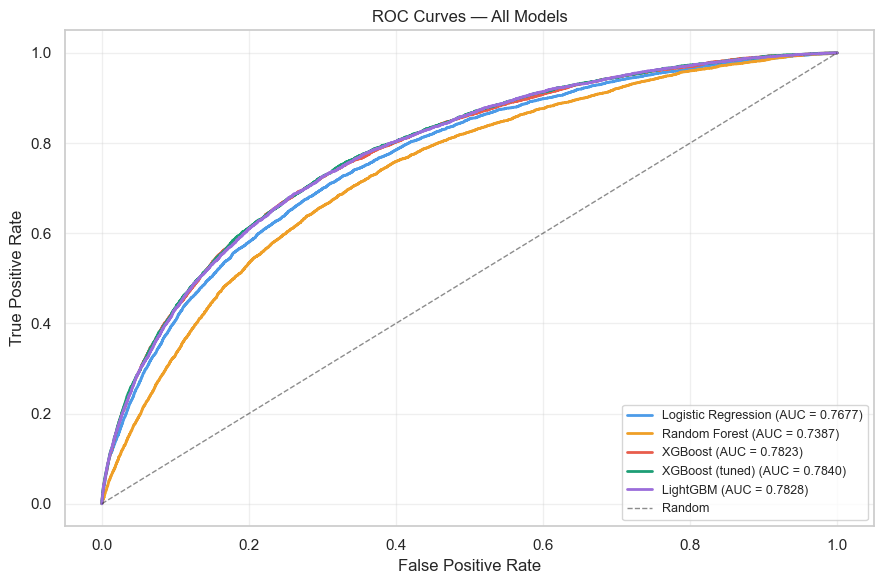

In [38]:
colors = ["#4C9BE8", "#EF9F27", "#E85D4C", "#1D9E75", "#9B6DDA"]

plt.figure(figsize=(9, 6))
for (name, prob), color in zip(probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

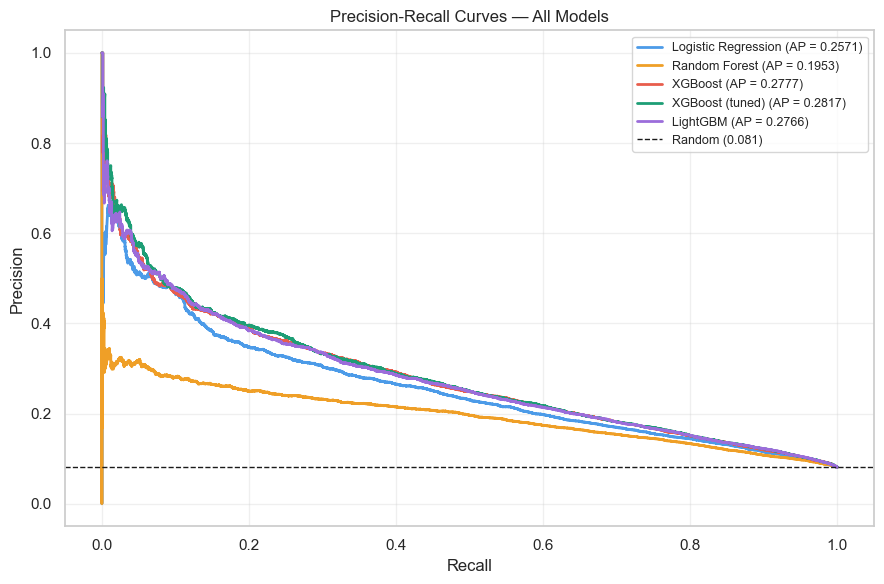

In [39]:
plt.figure(figsize=(9, 6))
for (name, prob), color in zip(probs.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(rec, prec, color=color, lw=2, label=f"{name} (AP = {ap:.4f})")

baseline_rate = y_test.mean()
plt.axhline(y=baseline_rate, color="k", linestyle="--", lw=1,
            label=f"Random ({baseline_rate:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Models")
plt.legend(loc="upper right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

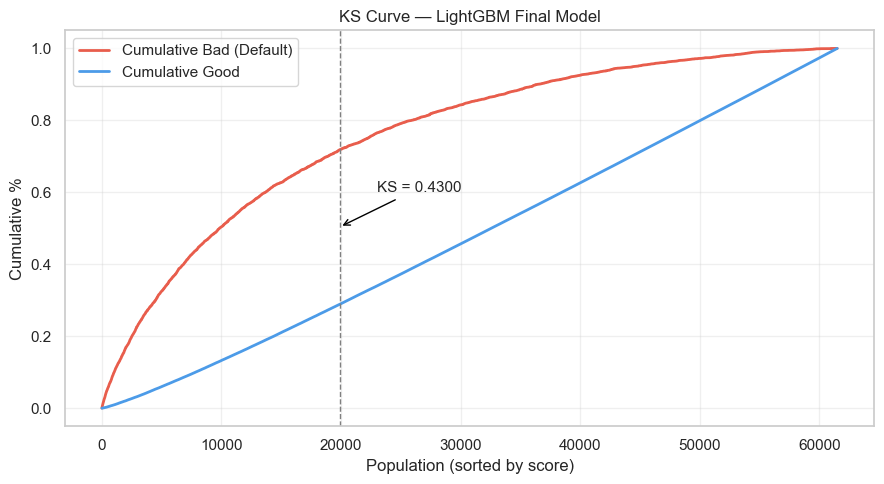

KS Statistic: 0.4300 


In [40]:
df_ks = pd.DataFrame({"y": y_test.values, "prob": final_probs})
df_ks = df_ks.sort_values("prob", ascending=False).reset_index(drop=True)

total_bad  = df_ks["y"].sum()
total_good = len(df_ks) - total_bad

df_ks["cum_bad"]  = df_ks["y"].cumsum() / total_bad
df_ks["cum_good"] = (1 - df_ks["y"]).cumsum() / total_good
df_ks["ks"]       = abs(df_ks["cum_bad"] - df_ks["cum_good"])

ks_stat = df_ks["ks"].max()
ks_idx  = df_ks["ks"].idxmax()

plt.figure(figsize=(9, 5))
plt.plot(df_ks["cum_bad"],  color="#E85D4C", lw=2, label="Cumulative Bad (Default)")
plt.plot(df_ks["cum_good"], color="#4C9BE8", lw=2, label="Cumulative Good")
plt.axvline(x=ks_idx, color="gray", linestyle="--", lw=1)
plt.annotate(f"KS = {ks_stat:.4f}",
             xy=(ks_idx, (df_ks.loc[ks_idx, "cum_bad"] + df_ks.loc[ks_idx, "cum_good"]) / 2),
             xytext=(ks_idx + len(df_ks)*0.05, 0.6),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=11)
plt.xlabel("Population (sorted by score)")
plt.ylabel("Cumulative %")
plt.title("KS Curve — LightGBM Final Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"KS Statistic: {ks_stat:.4f} ")

## 10. Probability Calibration

A well-ranked model is not necessarily well-calibrated. If the model outputs 0.30 for a group of applicants, roughly 30% of that group should actually default. Platt scaling (sigmoid) is applied using the held-out calibration set. `cv="prefit"` is used so the sigmoid is fitted on top of the already-trained model without refitting it.

In [43]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from scipy.special import expit
from scipy.optimize import curve_fit

if final_model is final_xgb_model:
    _cols          = X_train_imp.columns.tolist()
    _ref           = X_train_imp
    X_eval_aligned = X_test_imp
else:
    _cols          = X_train_sel.columns.tolist()
    _ref           = X_train_sel
    X_eval_aligned = X_test_sel

X_calib_aligned = X_calib.reindex(columns=_cols, fill_value=np.nan)

for col in _cols:
    if X_calib_aligned[col].isna().any():
        X_calib_aligned[col] = X_calib_aligned[col].fillna(_ref[col].median())

raw_calib_probs = final_model.predict_proba(X_calib_aligned)[:, 1]
raw_eval_probs  = final_model.predict_proba(X_eval_aligned)[:, 1]

def sigmoid(x, a, b):
    return expit(a * x + b)

popt, _ = curve_fit(
    sigmoid,
    raw_calib_probs,
    y_calib.values,
    p0=[1.0, 0.0],
    maxfev=10000
)

a, b = popt
cal_probs = expit(a * raw_eval_probs + b)

cal_auc = roc_auc_score(y_test, cal_probs)
ens_auc = roc_auc_score(y_test, final_probs)


print(f"Platt params         : a={a:.4f}, b={b:.4f}")
print(f"Calibrated model AUC : {cal_auc:.4f}")
print(f"Ensemble AUC         : {ens_auc:.4f}")

X_eval = X_eval_aligned
y_eval = y_test

Platt params         : a=7.2194, b=-5.9210
Calibrated model AUC : 0.7828
Ensemble AUC         : 0.7856


## 11. Decision Threshold Optimisation

The default 0.5 cut-off is inappropriate for an imbalanced dataset. Two thresholds are evaluated:

- **Youden J** — maximises sensitivity + specificity simultaneously
- **Cost-sensitive** — assumes a false negative (approving a defaulter) costs 5× more than a false positive, which is a realistic assumption for a lending context

The cost-optimal threshold is used for the confusion matrix and downstream decision logic.

Optimal threshold (Youden J): 0.0626
Sensitivity at threshold: 0.6866
Specificity at threshold: 0.7391


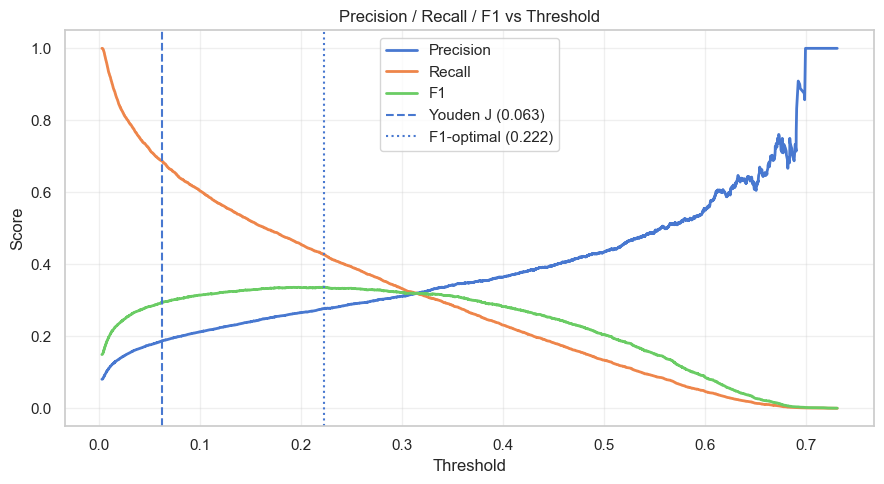

Youden J threshold : 0.0626
Cost-optimal threshold : 0.2224

Using decision threshold = 0.2224


In [44]:
fpr, tpr, thresholds = roc_curve(y_eval, cal_probs)

youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
opt_thresh = thresholds[best_idx]

print(f"Optimal threshold (Youden J): {opt_thresh:.4f}")
print(f"Sensitivity at threshold: {tpr[best_idx]:.4f}")
print(f"Specificity at threshold: {1 - fpr[best_idx]:.4f}")

prec_arr, rec_arr, thresholds_pr = precision_recall_curve(y_eval, cal_probs)

f1_arr = 2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-9)
best_f1_idx = np.argmax(f1_arr)
f1_opt_thresh = thresholds_pr[min(best_f1_idx, len(thresholds_pr) - 1)]

plt.figure(figsize=(9, 5))
plt.plot(thresholds_pr, prec_arr[:-1], lw=2, label="Precision")
plt.plot(thresholds_pr, rec_arr[:-1],  lw=2, label="Recall")
plt.plot(thresholds_pr, f1_arr[:-1],   lw=2, label="F1")

plt.axvline(x=opt_thresh, linestyle="--", lw=1.5,
            label=f"Youden J ({opt_thresh:.3f})")
plt.axvline(x=f1_opt_thresh, linestyle=":", lw=1.5,
            label=f"F1-optimal ({f1_opt_thresh:.3f})")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Youden J threshold : {opt_thresh:.4f}")

fn_cost, fp_cost = 5, 1
total_bad_eval  = y_eval.sum()
total_good_eval = len(y_eval) - total_bad_eval
cost = (fn_cost * (1 - tpr) * total_bad_eval +
        fp_cost * fpr       * total_good_eval)
cost_opt_thresh = thresholds[np.argmin(cost)]
print(f"Cost-optimal threshold : {cost_opt_thresh:.4f}")

DECISION_THRESHOLD = cost_opt_thresh
print(f"\nUsing decision threshold = {DECISION_THRESHOLD:.4f}")

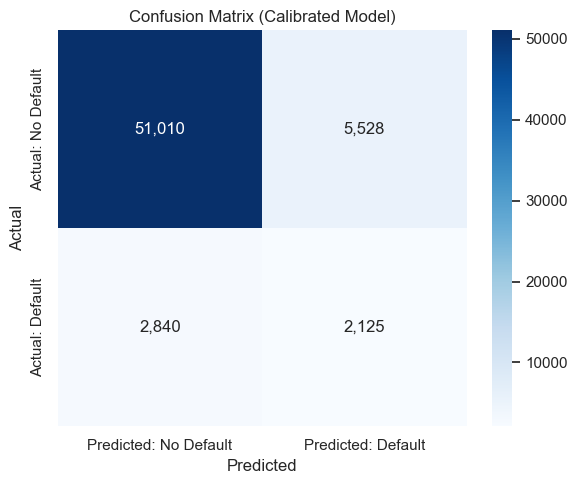

In [45]:
final_preds = (cal_probs >= DECISION_THRESHOLD).astype(int)

cm = confusion_matrix(y_eval, final_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=",d",
    cmap="Blues",
    xticklabels=["Predicted: No Default", "Predicted: Default"],
    yticklabels=["Actual: No Default", "Actual: Default"]
)

plt.title("Confusion Matrix (Calibrated Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 12. SHAP Explainability

Three views:
- **Bar plot** — mean absolute SHAP across the sample (global ranking)
- **Beeswarm** — distribution of SHAP values per feature, showing direction and spread
- **Waterfall** — per-applicant breakdown for a single test case

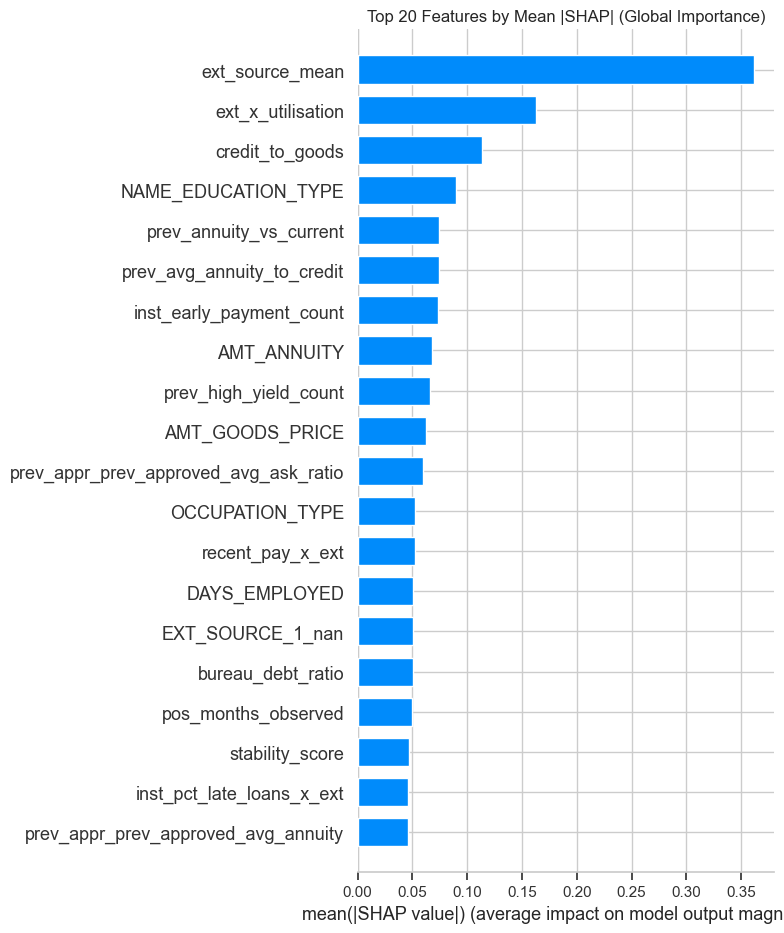

In [46]:
final_model_features = X_train_sel.columns.tolist() if final_model is not final_xgb_model else feature_cols

explainer   = shap.TreeExplainer(final_model)
shap_sample = X_eval.sample(SHAP_SAMPLE, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, shap_sample, plot_type="bar", max_display=20, show=False)
plt.title("Top 20 Features by Mean |SHAP| (Global Importance)")
plt.tight_layout()
plt.show()

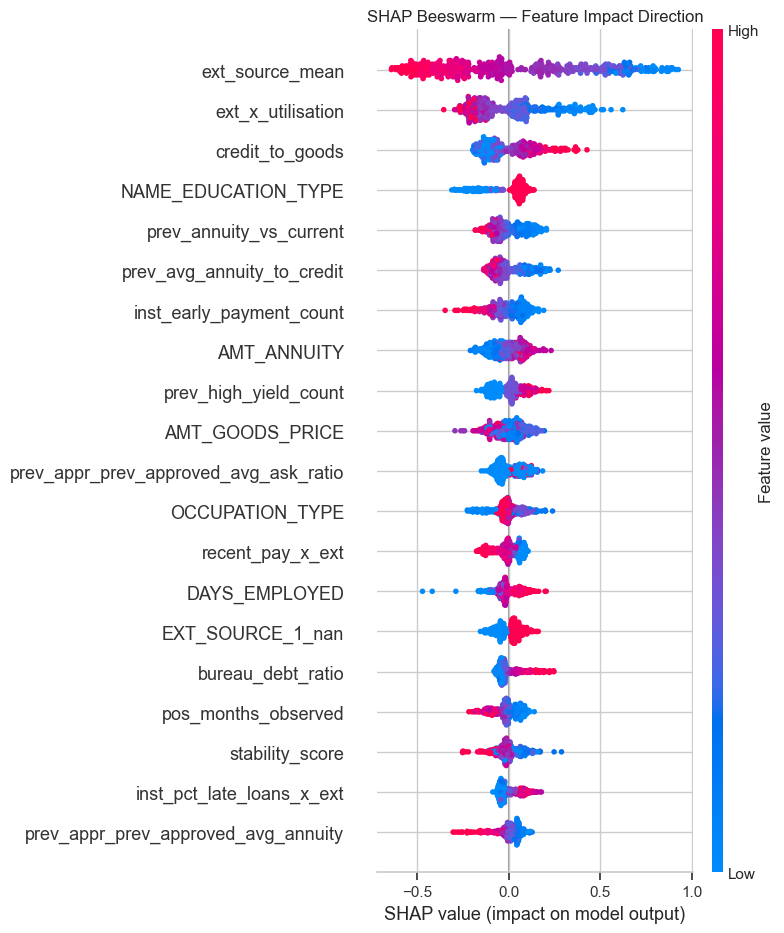

In [47]:
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, shap_sample, max_display=20, show=False)
plt.title("SHAP Beeswarm — Feature Impact Direction")
plt.tight_layout()
plt.show()

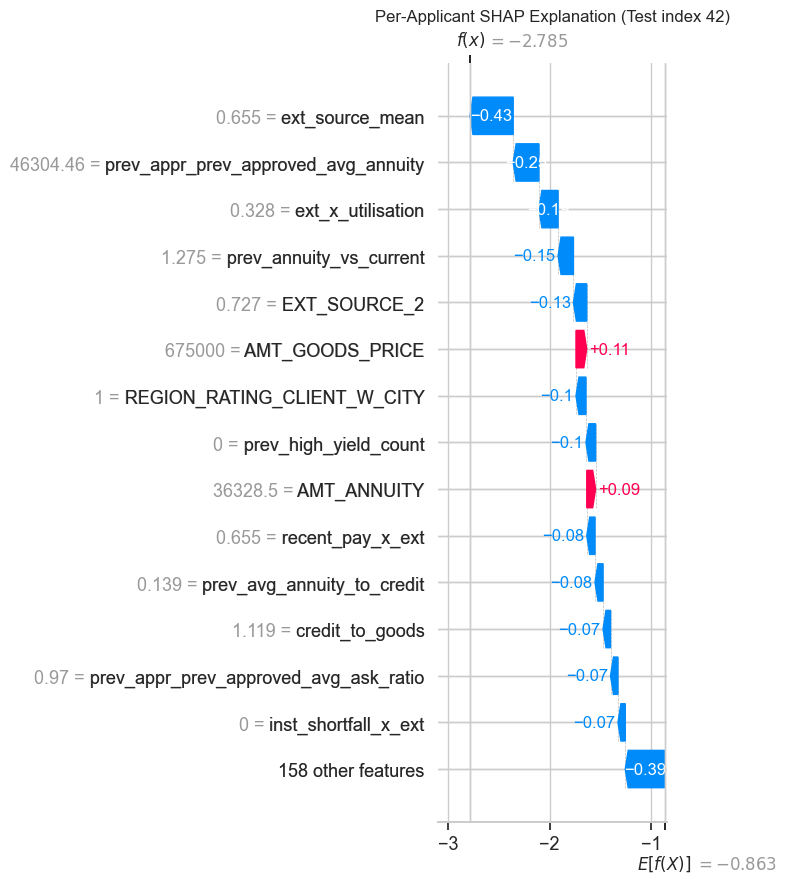


Default probability: 0.0264


In [48]:
sample_idx    = 42
single_sample = shap_sample.iloc[[sample_idx]]
single_sv     = explainer(single_sample)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(single_sv[0], max_display=15, show=False)
plt.title(f"Per-Applicant SHAP Explanation (Test index {sample_idx})")
plt.tight_layout()
plt.show()

pred_prob = cal_probs[shap_sample.index.get_loc(shap_sample.index[sample_idx])]
print(f"\nDefault probability: {pred_prob:.4f}")

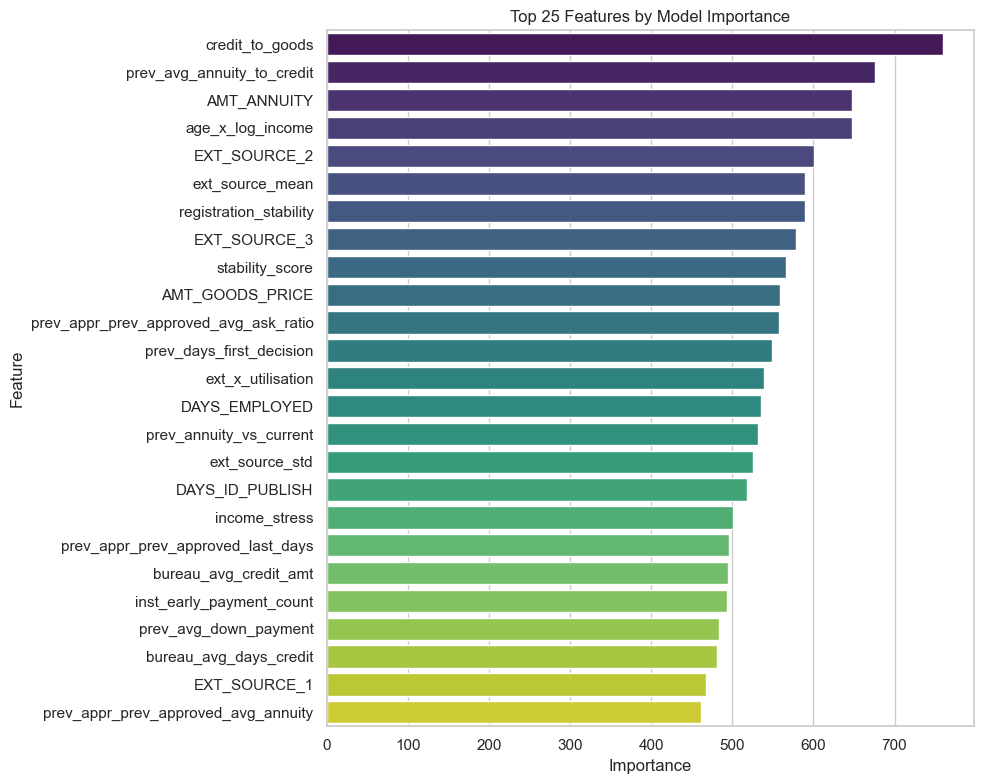


Top 15 features:
                              Feature  Importance
                      credit_to_goods         760
           prev_avg_annuity_to_credit         676
                          AMT_ANNUITY         648
                     age_x_log_income         647
                         EXT_SOURCE_2         601
                      ext_source_mean         590
               registration_stability         590
                         EXT_SOURCE_3         578
                      stability_score         566
                      AMT_GOODS_PRICE         559
prev_appr_prev_approved_avg_ask_ratio         557
             prev_days_first_decision         549
                    ext_x_utilisation         539
                        DAYS_EMPLOYED         535
              prev_annuity_vs_current         532


In [49]:
final_model_features = X_train_sel.columns.tolist() if final_model is not final_xgb_model else feature_cols

importance = pd.DataFrame({
    "Feature"    : final_model_features,
    "Importance" : final_model.feature_importances_,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance.head(25),
    x="Importance", y="Feature",
    palette="viridis"
)
plt.title("Top 25 Features by Model Importance")
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(importance.head(15).to_string(index=False))

## 13. Fairness Audit

**Protected attributes removed from the model:** gender, family status, and organisation type.

**Four-fifths rule:** The approval rate for any subgroup must be at least 80% of the highest-approval group. Bars in red indicate groups that fall below the threshold. Audited across income quartiles and age bands.

In [50]:
audit = X_eval.copy()

audit["actual"]    = y_eval.values
audit["prob"]      = cal_probs
audit["predicted"] = final_preds
audit["approved"]  = (final_preds == 0).astype(int)

print(audit.shape)
audit.head()

(61503, 176)


,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_HOUSING_TYPE,DAYS_EMPLOYED,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,NONLIVINGAREA_AVG,YEARS_BEGINEXPLUATATION_MEDI,LANDAREA_MEDI,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,bureau_active_loans,bureau_closed_loans,bureau_total_credit_amt,...,log_AMT_GOODS_PRICE,log_bureau_total_debt,log_bureau_total_credit_amt,log_bureau_total_overdue,credit_velocity,pensioner_x_annuity,bureau_consumer_total_debt,bureau_consumer_active,bureau_cc_count,bureau_cc_total_debt,bureau_cc_active,bureau_active_credit_total,bureau_recent_count,bureau_recent_total_debt,inst_min_loan_late_rate,inst_std_loan_late_rate,inst_loans_ever_late,inst_max_underpay_rate,inst_avg_loan_pay_ratio,inst_min_loan_pay_ratio,inst_r12_loan_count,prev_appr_prev_approved_avg_credit,prev_appr_prev_approved_max_credit,prev_appr_prev_approved_avg_annuity,prev_appr_prev_approved_avg_ask_ratio,prev_appr_prev_approved_last_days,prev_credit_shrinkage,worst_loan_x_ext,inst_pct_late_loans_x_ext,recent_loan_growth_x_ext,recent_refusal_x_ext,active_debt_x_ext,log_bureau_recent_count,log_bureau_active_credit_total,EXT_SOURCE_1_nan,EXT_SOURCE_3_nan,actual,prob,predicted,approved
0,0.0000,1.0000,1.0000,1.0000,30676.5000,688500.0000,1.0000,7.0000,1.0000,1.0000,-105.0000,-4402.0000,0.0000,8.0000,3.0000,2.0000,1.0000,17.0000,0.0000,0.0000,0.5054,0.5943,0.4277,0.0876,0.0764,0.0000,0.1379,0.1667,0.0036,0.9816,0.0487,0.0688,7.0000,2.0000,1.0000,1.0000,2.0000,4.0000,5.0000,1258366.5000,...,13.4423,12.1620,14.0453,0.0000,27.5707,0.0000,0.0000,1.0000,3.0000,191374.5600,3.0000,862119.0000,5.0000,191374.5600,0.0000,0.0500,0.0000,0.0000,0.9999,0.9999,1.0000,63685.5000,77611.5000,6589.0650,1.0293,-31.0000,0.0827,0.0000,0.0000,0.2445,0.0000,0.5942,1.7918,13.6671,1.0000,0.0000,0,0.0163,0,1
1,0.0000,0.0000,0.0000,0.0000,19926.0000,315000.0000,1.0000,7.0000,4.0000,1.0000,-4930.0000,-1259.0000,0.0000,8.0000,2.0000,2.0000,4.0000,12.0000,0.0000,0.0000,0.5936,0.6196,0.4849,0.0876,0.0764,0.0000,0.1379,0.1667,0.0036,0.9816,0.0487,0.0688,7.0000,2.0000,0.0000,0.0000,6.0000,1.0000,0.0000,81048.7800,...,12.6603,10.5071,11.3028,0.0000,6.9212,0.0000,36573.6600,1.0000,1.0000,31473.0000,1.0000,81048.7800,1.0000,36573.6600,0.0000,0.1337,3.0000,0.3889,0.9285,0.7221,3.0000,77751.0000,241920.0000,9572.4525,1.0288,-351.0000,0.2131,0.1447,0.1860,0.2170,0.4340,0.1764,0.6931,11.3028,0.0000,0.0000,0,0.0379,0,1
2,0.0000,0.0000,1.0000,0.0000,18643.5000,225000.0000,6.0000,7.0000,4.0000,1.0000,-1191.0000,-2474.0000,0.0000,16.0000,2.0000,2.0000,4.0000,4.0000,0.0000,0.0000,0.5054,0.0301,0.5389,0.0928,0.1035,0.0000,0.2069,0.1667,0.0007,0.9831,0.0724,0.0662,4.0000,0.0000,0.0000,0.0000,3.0000,0.0000,2.0000,202365.0000,...,12.3239,0.0000,12.2178,0.0000,3.1133,0.0000,0.0000,0.0000,1.0000,31473.0000,1.0000,647114.2200,2.0000,157279.5000,0.0000,0.1414,1.0000,0.1333,0.9666,0.9333,1.0000,121540.5000,203760.0000,10362.8925,1.0880,-451.0000,0.4274,0.1431,0.2385,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0,0.2306,1,0
3,0.0000,0.0000,0.0000,0.0000,38218.5000,873000.0000,6.0000,7.0000,1.0000,1.0000,-355.0000,-2289.0000,1.0000,3.0000,1.0000,3.0000,4.0000,14.0000,1.0000,1.0000,0.6287,0.4176,0.4118,0.0876,0.0764,0.0000,0.1379,0.1667,0.0036,0.9816,0.0487,0.0688,7.0000,2.0000,3.0000,0.0000,1.0000,2.0000,2.0000,992592.0000,...,13.6797,12.8017,13.8081,0.0000,4.2162,0.0000,362836.8450,1.0000,1.0000,0.0000,1.0000,537750.0000,3.0000,92238.3450,0.0000,0.0500,1.0000,0.0000,0.9998,0.9996,1.0000,90000.0000,90000.0000,4500.0000,1.0000,-757.0000,0.0921,0.0000,0.0000,0.30

In [51]:
required_cols = ["actual", "predicted", "approved", "prob"]
missing = [col for col in required_cols if col not in audit.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

age_available = True

if "DAYS_BIRTH" in audit.columns:
    audit["age"] = (-audit["DAYS_BIRTH"]) / 365
elif "age" in audit.columns:
    pass
elif "AGE" in audit.columns:
    audit["age"] = audit["AGE"]
elif "DOB" in audit.columns:
    audit["DOB"] = pd.to_datetime(audit["DOB"])
    audit["age"] = (pd.Timestamp.today() - audit["DOB"]).dt.days / 365
else:
    print("No age column found — skipping AGE fairness")
    age_available = False

if age_available:
    audit = audit[(audit["age"] >= 18) & (audit["age"] <= 100)]
    audit["age_group"] = pd.cut(
        audit["age"],
        bins=[18, 25, 35, 45, 55, 65, 100],
        labels=["18-25", "25-35", "35-45", "45-55", "55-65", "65+"],
        right=False
    )

income_available = True
if "AMT_INCOME_TOTAL" in audit.columns:
    audit["income_group"] = pd.qcut(
        audit["AMT_INCOME_TOTAL"],
        q=4,
        labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
    )
else:
    print("No income column found — skipping INCOME fairness")
    income_available = False

audit["correct"] = (audit["actual"] == audit["predicted"]).astype(int)

if age_available:
    age_stats = audit.groupby("age_group", observed=True).agg(
        count=("actual", "count"),
        actual_default=("actual", "mean"),
        approval_rate=("approved", "mean"),
        accuracy=("correct", "mean")
    ).round(4)
    max_approval_age = age_stats["approval_rate"].max()
    age_stats["disparate_impact_ratio"] = age_stats["approval_rate"] / max_approval_age
    age_stats["passes_4_5_rule"] = age_stats["disparate_impact_ratio"] >= 0.80
    print("=" * 60)
    print("FAIRNESS AUDIT — AGE")
    print("=" * 60)
    print(age_stats.to_string())

if income_available:
    income_stats = audit.groupby("income_group", observed=True).agg(
        count=("actual", "count"),
        actual_default=("actual", "mean"),
        approval_rate=("approved", "mean"),
        accuracy=("correct", "mean")
    ).round(4)
    max_approval_income = income_stats["approval_rate"].max()
    income_stats["disparate_impact_ratio"] = income_stats["approval_rate"] / max_approval_income
    income_stats["passes_4_5_rule"] = income_stats["disparate_impact_ratio"] >= 0.80
    print("\n" + "=" * 60)
    print("FAIRNESS AUDIT — INCOME")
    print("=" * 60)
    print(income_stats.to_string())

plots = []
if income_available:
    plots.append("income")
if age_available:
    plots.append("age")

n_plots = len(plots)
if n_plots == 0:
    print("No plots to display")
else:
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    i = 0
    if income_available:
        income_stats["approval_rate"].plot(
            kind="bar", ax=axes[i],
            color=["#E85D4C" if not p else "#1D9E75" for p in income_stats["passes_4_5_rule"]],
            edgecolor="white"
        )
        axes[i].axhline(y=max_approval_income * 0.8, linestyle="--", lw=1.5, label="80% threshold")
        axes[i].set_title("Approval Rate by Income")
        axes[i].set_ylabel("Approval Rate")
        axes[i].legend()
        axes[i].tick_params(axis="x", rotation=30)
        i += 1
    if age_available:
        age_stats["approval_rate"].plot(
            kind="bar", ax=axes[i],
            color=["#E85D4C" if not p else "#1D9E75" for p in age_stats["passes_4_5_rule"]],
            edgecolor="white"
        )
        axes[i].axhline(y=max_approval_age * 0.8, linestyle="--", lw=1.5, label="80% threshold")
        axes[i].set_title("Approval Rate by Age")
        axes[i].set_ylabel("Approval Rate")
        axes[i].legend()
        axes[i].tick_params(axis="x", rotation=30)
    plt.suptitle("Fairness Audit — Four-Fifths Rule", fontsize=13)
    plt.tight_layout()
    plt.show()

audit["adj_score"]    = [int(SCORE_MIN + (1 - p) * (SCORE_MAX - SCORE_MIN)) for p in audit["prob"]]
audit["adj_approved"] = (audit["adj_score"] >= REVIEW_THRESHOLD).astype(int)

print("\n--- FINAL CHECK ---")
print("Original approval:", audit["approved"].mean())
print("Adjusted approval:", audit["adj_approved"].mean())
print("\nDefault rate among approved:")
print(audit[audit["adj_approved"] == 1]["actual"].mean())

No age column found — skipping AGE fairness
No income column found — skipping INCOME fairness
No plots to display

--- FINAL CHECK ---
Original approval: 0.8755670455099751
Adjusted approval: 0.9541323187486789

Default rate among approved:
0.06647694352612385


## 14. Credit Score Function

Default probability is mapped to a 300–900 integer score, matching the range used by Indian credit bureaus. The mapping is a linear inversion: higher default probability → lower score.

Decision bands: **≥ 750** → Approve | **650–749** → Review / lower limit | **< 650** → Decline

Each applicant report surfaces the top 5 SHAP contributors so an underwriter or applicant can understand what drove the score.

In [54]:
def compute_credit_score(prob):
    return round(SCORE_MIN + (1 - prob) * (SCORE_MAX - SCORE_MIN), 1)

def loan_decision(score, prob):
    if score >= APPROVE_THRESHOLD:
        return "APPROVE", "#1D9E75"
    elif score >= REVIEW_THRESHOLD:
        return "APPROVE WITH LOWER LIMIT", "#EF9F27"
    else:
        return "DECLINE", "#E85D4C"

def explain_applicant(idx, X_df, model, explainer, model_features, platt_a, platt_b):
    sample      = X_df.iloc[[idx]]
    raw_prob    = model.predict_proba(sample)[0][1]
    prob        = float(expit(platt_a * raw_prob + platt_b))
    score       = compute_credit_score(prob)
    decision, _ = loan_decision(score, prob)

    print("═" * 50)
    print("  CREDIT DECISION REPORT")
    print("═" * 50)
    print(f"  Credit Score         : {score}  /  {SCORE_MAX}")
    print(f"  Default Probability  : {prob:.4f}  ({prob*100:.1f}%)")
    print(f"  Decision             : {decision}")
    print("═" * 50)

    if score >= 800:
        print("  Risk band            : PRIME (Very Low Risk)")
    elif score >= 700:
        print("  Risk band            : NEAR-PRIME (Low Risk)")
    elif score >= 600:
        print("  Risk band            : SUB-PRIME (Moderate Risk)")
    else:
        print("  Risk band            : HIGH RISK")
    print("═" * 50)

    sv  = explainer.shap_values(sample)
    sv1 = sv[1][0] if isinstance(sv, list) else sv[0]

    feat_impact = pd.Series(sv1, index=model_features).abs().sort_values(ascending=False)

    print("\n  Top 5 factors influencing this score:")
    for feat, imp in feat_impact.head(5).items():
        val       = sample[feat].values[0]
        direction = "↑ risk" if sv1[list(model_features).index(feat)] > 0 else "↓ risk"
        print(f"  • {feat:<40} {direction}  (value={val:.3f})")
    print()

final_model_features = X_train_sel.columns.tolist() if final_model is not final_xgb_model else feature_cols

X_eval_reset = X_eval.reset_index(drop=True)
for idx in [0, 50, 200]:
    explain_applicant(idx, X_eval_reset, final_model, explainer, final_model_features, a, b)

══════════════════════════════════════════════════
  CREDIT DECISION REPORT
══════════════════════════════════════════════════
  Credit Score         : 890.2  /  900
  Default Probability  : 0.0163  (1.6%)
  Decision             : APPROVE
══════════════════════════════════════════════════
  Risk band            : PRIME (Very Low Risk)
══════════════════════════════════════════════════

  Top 5 factors influencing this score:
  • NAME_EDUCATION_TYPE                      ↓ risk  (value=1.000)
  • ext_x_utilisation                        ↓ risk  (value=0.511)
  • prev_annuity_vs_current                  ↑ risk  (value=0.215)
  • AMT_GOODS_PRICE                          ↓ risk  (value=688500.000)
  • DAYS_EMPLOYED                            ↑ risk  (value=-105.000)

══════════════════════════════════════════════════
  CREDIT DECISION REPORT
══════════════════════════════════════════════════
  Credit Score         : 897.0  /  900
  Default Probability  : 0.0050  (0.5%)
  Decision           

## 15. Sample Results

Score distribution on the test set split by actual default outcome, with decision band boundaries overlaid.

In [55]:
results_table = pd.DataFrame({
    "Default_Prob"   : cal_probs,
    "Credit_Score"   : [compute_credit_score(p) for p in cal_probs],
    "Actual_Default" : y_eval.values,   
    "Predicted"      : final_preds,
})

results_table["Decision"] = results_table["Credit_Score"].apply(
    lambda s: loan_decision(s, 0)[0]
)

results_table["Correct"] = (
    results_table["Actual_Default"] == results_table["Predicted"]
)

print(results_table.shape)
results_table.head()

(61503, 6)


,Default_Prob,Credit_Score,Actual_Default,Predicted,Decision,Correct
0,0.0163,890.2000,0,0,APPROVE,True
1,0.0379,877.3000,0,0,APPROVE,True
2,0.2306,761.6000,0,1,APPROVE,False
3,0.0094,894.3000,0,0,APPROVE,True
4,0.0581,865.2000,0,0,APPROVE,True


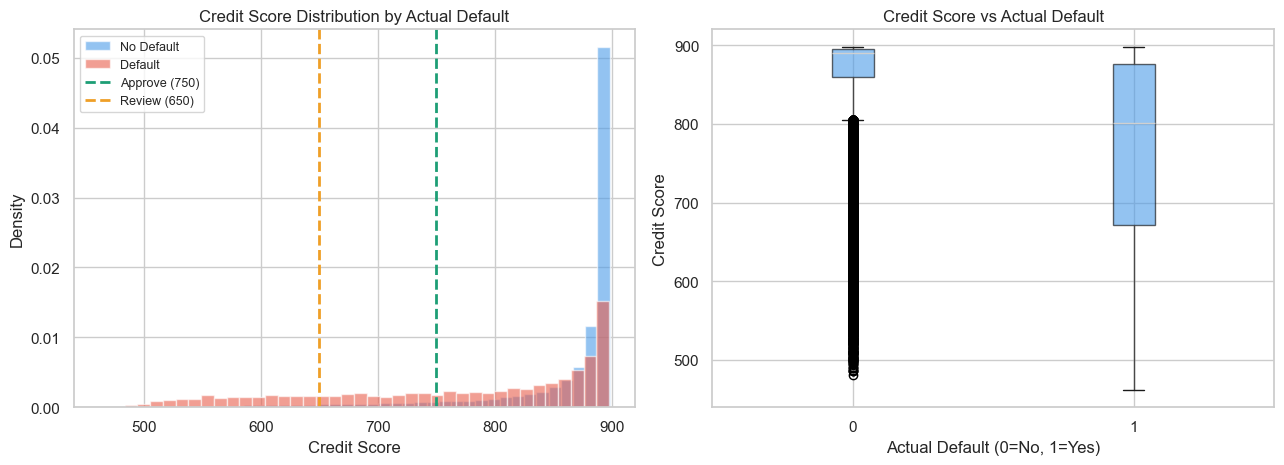

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for t, color, label in [(0, "#4C9BE8", "No Default"), (1, "#E85D4C", "Default")]:
    scores = results_table.loc[results_table["Actual_Default"] == t, "Credit_Score"]
    axes[0].hist(scores, bins=40, alpha=0.6, color=color, label=label, density=True)

for x, label, color in [
    (APPROVE_THRESHOLD, "Approve",  "#1D9E75"),
    (REVIEW_THRESHOLD,  "Review",   "#EF9F27")
]:
    axes[0].axvline(x=x, color=color, linestyle="--", lw=2, label=f"{label} ({x})")

axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Density")
axes[0].set_title("Credit Score Distribution by Actual Default")
axes[0].legend(fontsize=9)

results_table.boxplot(
    column="Credit_Score", by="Actual_Default", ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor="#4C9BE8", alpha=0.6)
)
axes[1].set_title("Credit Score vs Actual Default")
axes[1].set_xlabel("Actual Default (0=No, 1=Yes)")
axes[1].set_ylabel("Credit Score")
plt.suptitle("")

plt.tight_layout()
plt.show()

## 16. Final Summary

In [67]:
best_result = results_df.iloc[0]
print("╔═══════════════════════════════════════════════════════════╗")
print("║          AI-POWERED CREDIT SCORING — FINAL SUMMARY        ║")
print("╠═══════════════════════════════════════════════════════════╣")
print(f"║  Dataset         : Home Credit Default Risk               ║")
print(f"║  Training rows   : {len(X_train_sm):>8,}  (post-SMOTE)                 ║")
print(f"║  Test rows       : {len(X_test_imp):>8,}                               ║")
print(f"║  Feature count   : {len(feature_cols):>8,}                               ║")
print("╠═══════════════════════════════════════════════════════════╣")
print(f"║  Best model      :{results_df.index[0]:<40}║")
print(f"║  AUC-ROC         : {best_result['AUC-ROC']:>8.4f}                               ║")
print(f"║  Avg Precision   : {best_result['Avg Prec']:>8.4f}                               ║")
print(f"║  F1 Score        : {best_result['F1']:>8.4f}                               ║")
print(f"║  KS Statistic    : {ks_stat:>8.4f}                               ║")
print("╠═══════════════════════════════════════════════════════════╣")
print(f"║  Decision threshold : {DECISION_THRESHOLD:.4f} (Youden J optimised)         ║")
print(f"║  Credit score range : {SCORE_MIN}–{SCORE_MAX} (Indian bureau style)       ║")
print(f"║  Approve threshold  : {APPROVE_THRESHOLD}+                                ║")
print(f"║  Review threshold   : {REVIEW_THRESHOLD}–{APPROVE_THRESHOLD-1}                             ║")
print("╠═══════════════════════════════════════════════════════════╣")
print("║  Fairness: Protected attributes removed (gender)          ║")
print("║  Fairness: Four-fifths rule audited (income + age)        ║")
print("║  Explainability: SHAP global + per-applicant waterfall    ║")
print("║  Calibration: Platt scaling applied                       ║")
print("╚═══════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════╗
║          AI-POWERED CREDIT SCORING — FINAL SUMMARY        ║
╠═══════════════════════════════════════════════════════════╣
║  Dataset         : Home Credit Default Risk               ║
║  Training rows   :  407,066  (post-SMOTE)                 ║
║  Test rows       :   61,503                               ║
║  Feature count   :      204                               ║
╠═══════════════════════════════════════════════════════════╣
║  Best model      :Ensemble                                ║
║  AUC-ROC         :   0.7856                               ║
║  Avg Precision   :   0.2825                               ║
║  F1 Score        :   0.2369                               ║
║  KS Statistic    :   0.4300                               ║
╠═══════════════════════════════════════════════════════════╣
║  Decision threshold : 0.2224 (Youden J optimised)         ║
║  Credit score range : 300–900 (Indian bureau style)       ║
║  Appro